In [1]:

#by Henry Schumacher
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import time
start_setup = time.process_time_ns()
print('---------------------------------------')
print(time.strftime("CyclotronKW16.ipynb started: %a, %d %b %Y %H:%M:%S", time.localtime()))
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import os
import sys
import csv
import json
import uuid
import h5py
import math
import xraydb
import plotly
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import numpy as np
import pandas as pd
# import pyxray as xy
import odrpack as odr
import seaborn as sb
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from scipy.signal import find_peaks, argrelmax
from scipy.optimize import curve_fit
from scipy.special import voigt_profile
from getmac import get_mac_address as gma
from itertools import chain
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, VPacker
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
from colors import load_colors
from Cyc_functions import lin_func, evaluator_scipy, energy_func
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.usetex": True,
    "font.size": 8,
    "pgf.rcfonts": False
})


plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": "\n".join([
          r'\usepackage{amsmath}',
     ]),
})

#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
color_schemes = load_colors()


end_setup = time.process_time_ns()
elapsed_setup = (end_setup - start_setup)/1e6

print(f'INFO: SETUP COMPLETE ({elapsed_setup:.2f} ms)')
print('---------------------------------------')
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

---------------------------------------
CyclotronKW16.ipynb started: Thu, 30 Apr 2026 14:05:17
INFO: SETUP COMPLETE (1125.00 ms)
---------------------------------------


## Loading Measurement Data

In [3]:
# df = pd.read_csv('./2026_KW12/KW12_measurement.csv', header=0, delimiter=',')
# print(df)

### HF Preselect Skt vs. Voltage

In [4]:
# init_values = [0.1,1]
# x_data = df.iloc[:,2].tolist()
# y_data = df.iloc[:,1].tolist()
# x_err = np.array([0.1]*len(x_data))
# y_err = np.array([2.0]*len(x_data))

# beta = evaluator_scipy(func=lin_func, beta0_list=init_values,
#                            x=x_data, y=y_data,
#                            xerr=x_err, yerr=y_err)

# param_h = [beta['param'][0] + beta['errors'][0], beta['param'][1] + beta['errors'][1]]
# param_l = [beta['param'][0] - beta['errors'][0], beta['param'][1] - beta['errors'][1]]

In [5]:
# DPI = 250
# x_lin = np.linspace(30,50,1000)
# plt.figure(figsize=(6,3), dpi=DPI)
# plt.scatter(df.iloc[:,2],df.iloc[:,1],s=12,marker='x',lw=1, c=color_schemes['c_dark'][0], zorder=3)
# plt.plot(x_lin,lin_func(beta['param'],x_lin),lw=0.75, color=color_schemes['c_dark'][3], zorder=2, label=f'm = {round(beta['param'][0],3)} Skt/mV \n b = {round(beta['param'][1],3)} Skt')
# plt.fill_between(x_lin,lin_func(param_l,x_lin),lin_func(param_h,x_lin),alpha=0.25, color='black', zorder=2, label=r'$1\sigma$-error')

# plt.xlim(32,49)
# plt.ylim(620,1000)

# plt.xlabel('HF Voltage / mV')
# plt.ylabel('HF Preselect / Skt')
# plt.grid()
# plt.legend()
# plt.tight_layout()
# plt.title('HF Preselect Skt vs. HF DMM mV')

# plt.savefig('PreselectVsDMM.pdf', dpi=DPI)
# plt.show()

## Heatmap

In [6]:
# transEff = df.pivot_table(index='HF Preselect / Skt', columns='HF Frequency / MHz', values='TransEffProcent', aggfunc='mean').iloc[::-1]

# # print(transEff)
# plt.figure(figsize=(5,5), dpi=300)

# sb.heatmap(transEff, annot=True, fmt=".2f", annot_kws={'fontsize':4}, cmap='flare', cbar_kws={'label':'Transfereffizienz in Prozent'}, linewidths=0.1)
# plt.tight_layout()
# plt.savefig('Transfereffizienz2.pdf', dpi=300)


### Dichteschriebe

In [2]:
ds_info = {'./2026_KW16/DS_2.txt':'Baseline',
           './2026_KW16/DS_3.txt':'R7 on 500 Skt',
           './2026_KW16/DS_4.txt':'R6 on 500 Skt',
           './2026_KW16/DS_5.txt':'R5 on 500 Skt',
           './2026_KW16/DS_6.txt':'R4 on 500 Skt',
           './2026_KW16/DS_7.txt':'R3 on 500 Skt',
           './2026_KW16/DS_8.txt':'R2 on 500 Skt',
           './2026_KW16/DS_9.txt':'R1 on 500 Skt',
           './2026_KW16/DS_10.txt':'all on 500 Skt'}

In [3]:
def DichteschriebPlot(filename:str, ds_info:dict, peak_flag:bool=True, grad_flag:bool=False):
    df = pd.read_csv(filename, skiprows=8, delimiter='\t', decimal=",")
    
    # freq = ds_info[filename].split('/')[0]
    # skt = ds_info[filename].split('/')[1]
    # Teff = ds_info[filename].split('/')[2]
    if len(ds_info[filename].split('/')) > 3:
        info = ds_info[filename].split('/')[3]
    
    if (peak_flag == True):
        peaks = find_peaks(np.array(df['Real'].tolist()),height=1.0,prominence=0.5)
        # print(peaks[0])
    
    plt.figure(figsize=(12,4), dpi=300)
    
    plt.plot(df['Real.1']*100, df['Real'], color=color_schemes['c_five'][1], lw=1, zorder=2, label=f'{ds_info[filename]}')
    if (grad_flag == True):
        plt.plot(df['Real.1']*100, np.gradient(df['Real']), color=color_schemes['c_five'][2], lw=1, zorder=2, label=f'Gradient of data')
    if (peak_flag == True):
        plt.scatter(df['Real.1'][peaks[0][0]]*100, df['Real'][peaks[0][0]], s=13, marker='x', lw=0.8, color=color_schemes['c_dark'][0], label=f'Detected first peaks: {df['Real.1'][peaks[0][0]]*100:.2f}', zorder=3, alpha=0.5)
        plt.scatter(df['Real.1'][peaks[0][-1]]*100, df['Real'][peaks[0][-1]], s=13, marker='x', lw=0.8, color=color_schemes['c_dark'][0], label=f'Detected final peaks: {df['Real.1'][peaks[0][-1]]*100:.2f}', zorder=3, alpha=0.5)
    
    
    plt.xticks(np.arange(150,1050,50),np.arange(150,1050,50))
    plt.xlim(100,1000)
    
    plt.xlabel('Radial Position / mm')
    plt.ylabel('Beam Intensity / a.u.')
    
    plt.grid(which='both')
    plt.legend()
    plt.tight_layout()
    
    if (peak_flag == True):
        plt.savefig(f'./Dichteschriebe_python/{filename.split('/')[2].split('.')[0]}_peaks_firstlast.pdf', dpi=300)
    elif (grad_flag == True):
        plt.savefig(f'./Dichteschriebe_python/{filename.split('/')[2].split('.')[0]}_grad.pdf', dpi=300)
    else:
        plt.savefig(f'./Dichteschriebe_python/{filename.split('/')[2].split('.')[0]}.pdf', dpi=300)

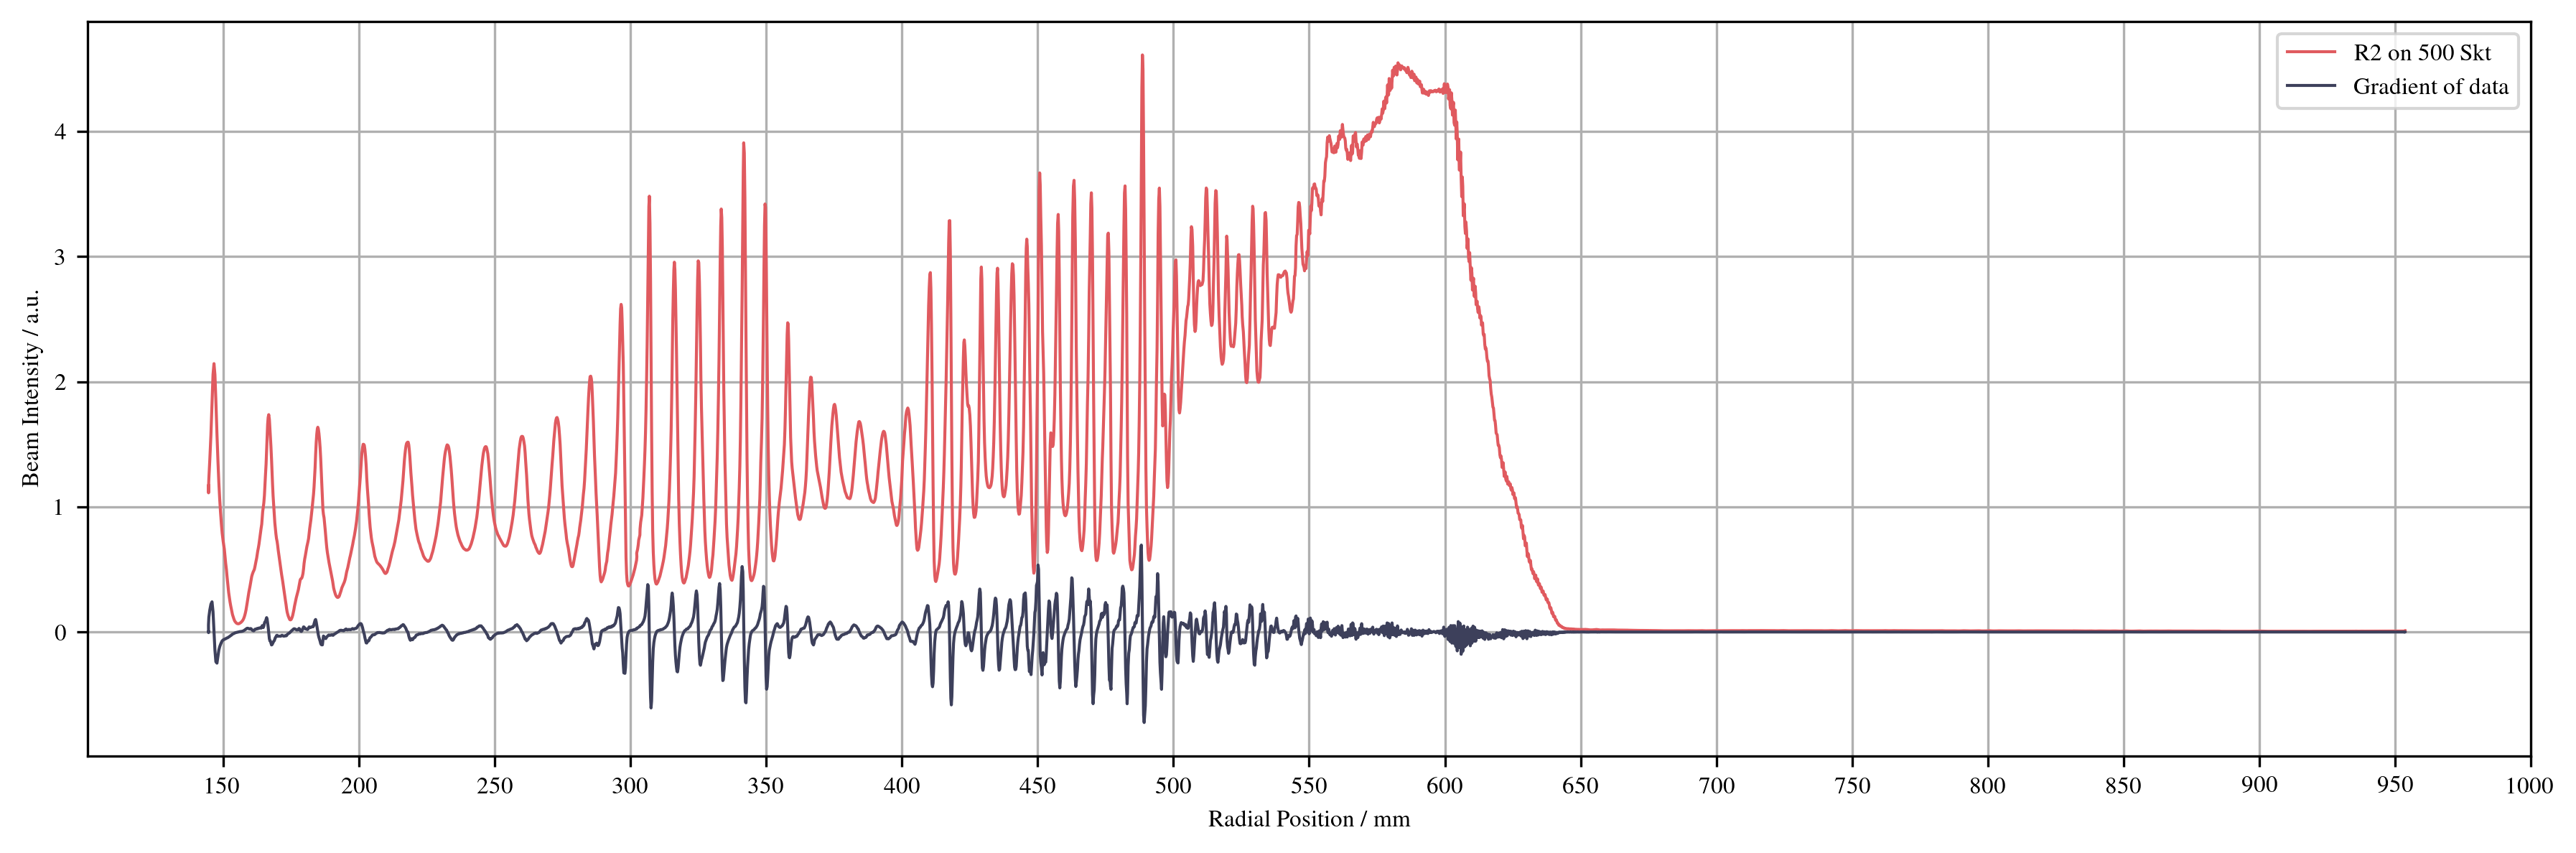

In [53]:
DichteschriebPlot('./2026_KW16/DS_8.txt',ds_info,peak_flag=False,grad_flag=True)

./2026_KW16/DS_10.txt
./2026_KW16/DS_2.txt
./2026_KW16/DS_3.txt
./2026_KW16/DS_4.txt
./2026_KW16/DS_5.txt
./2026_KW16/DS_6.txt
./2026_KW16/DS_7.txt
./2026_KW16/DS_8.txt
./2026_KW16/DS_9.txt


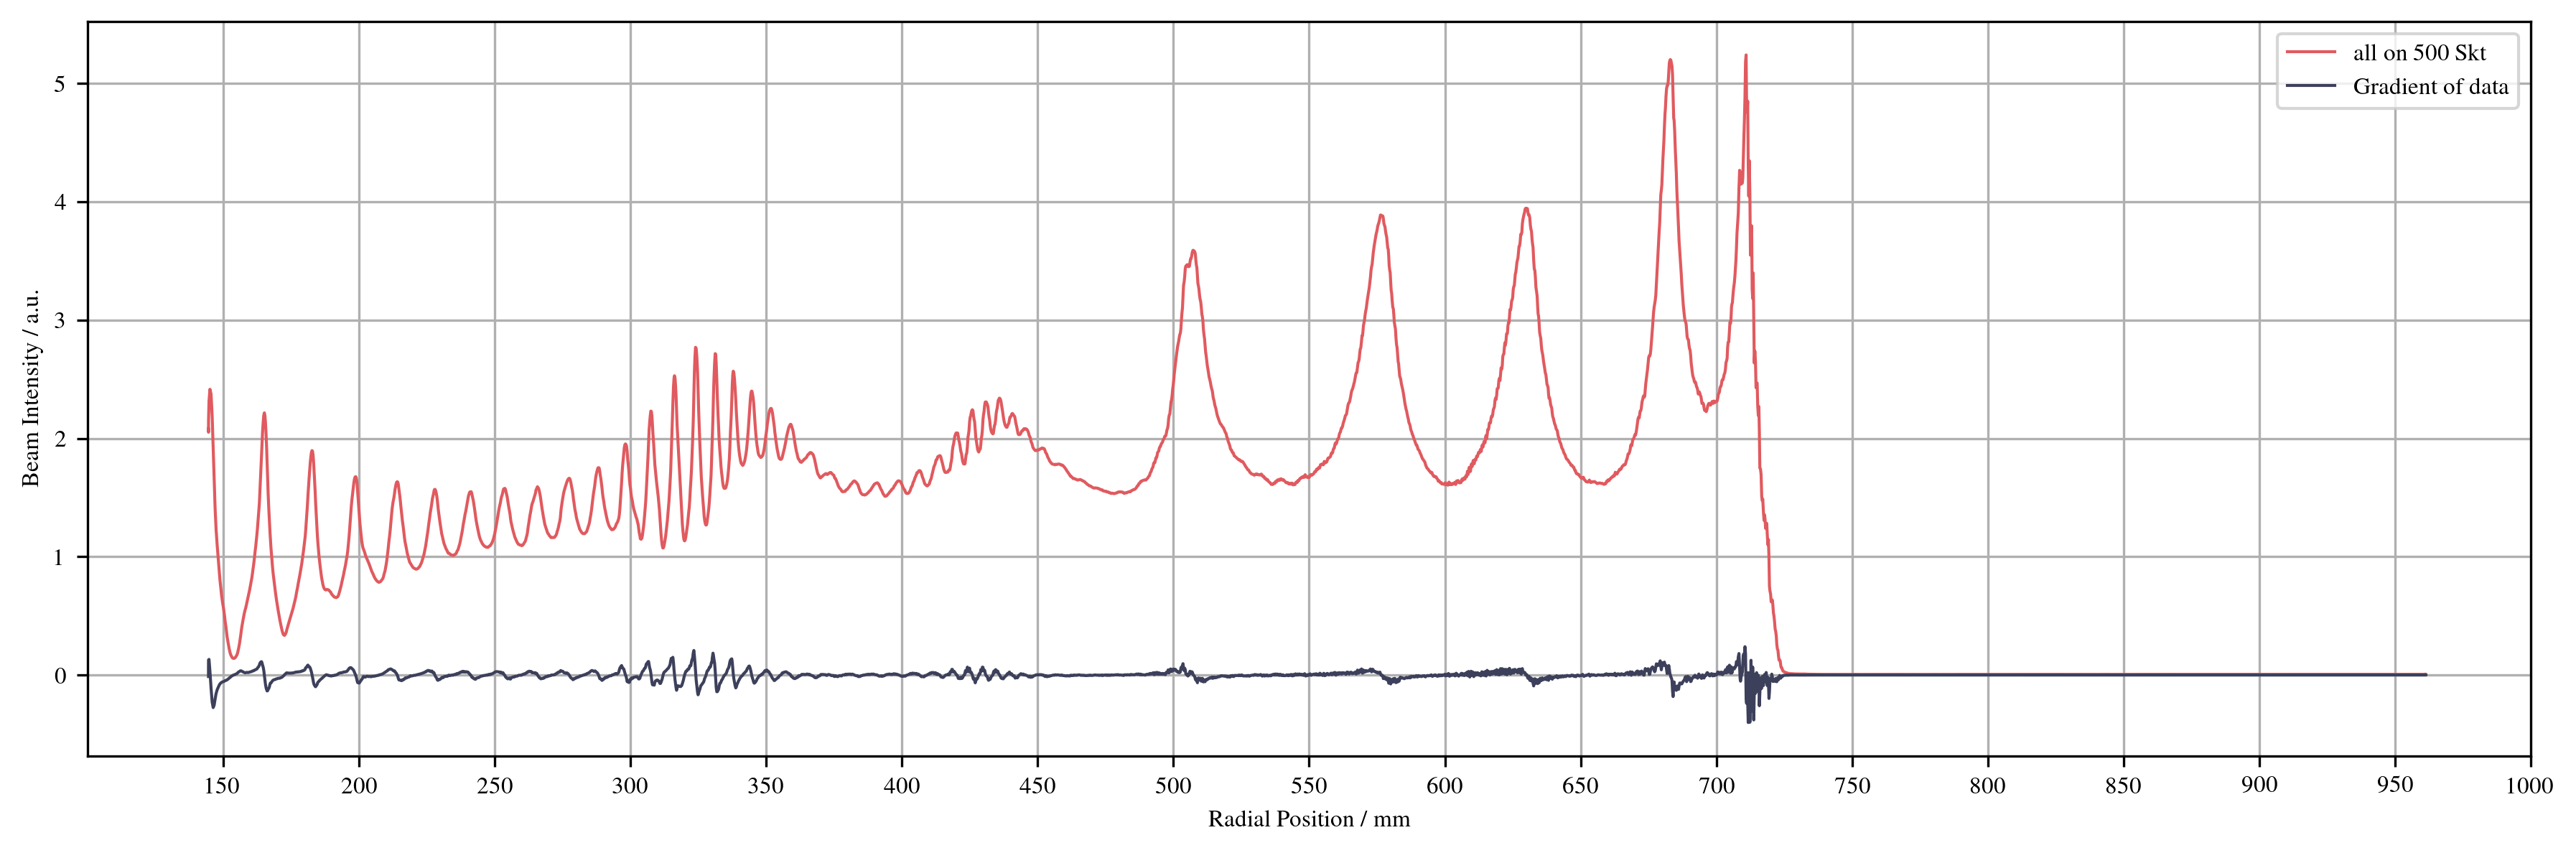

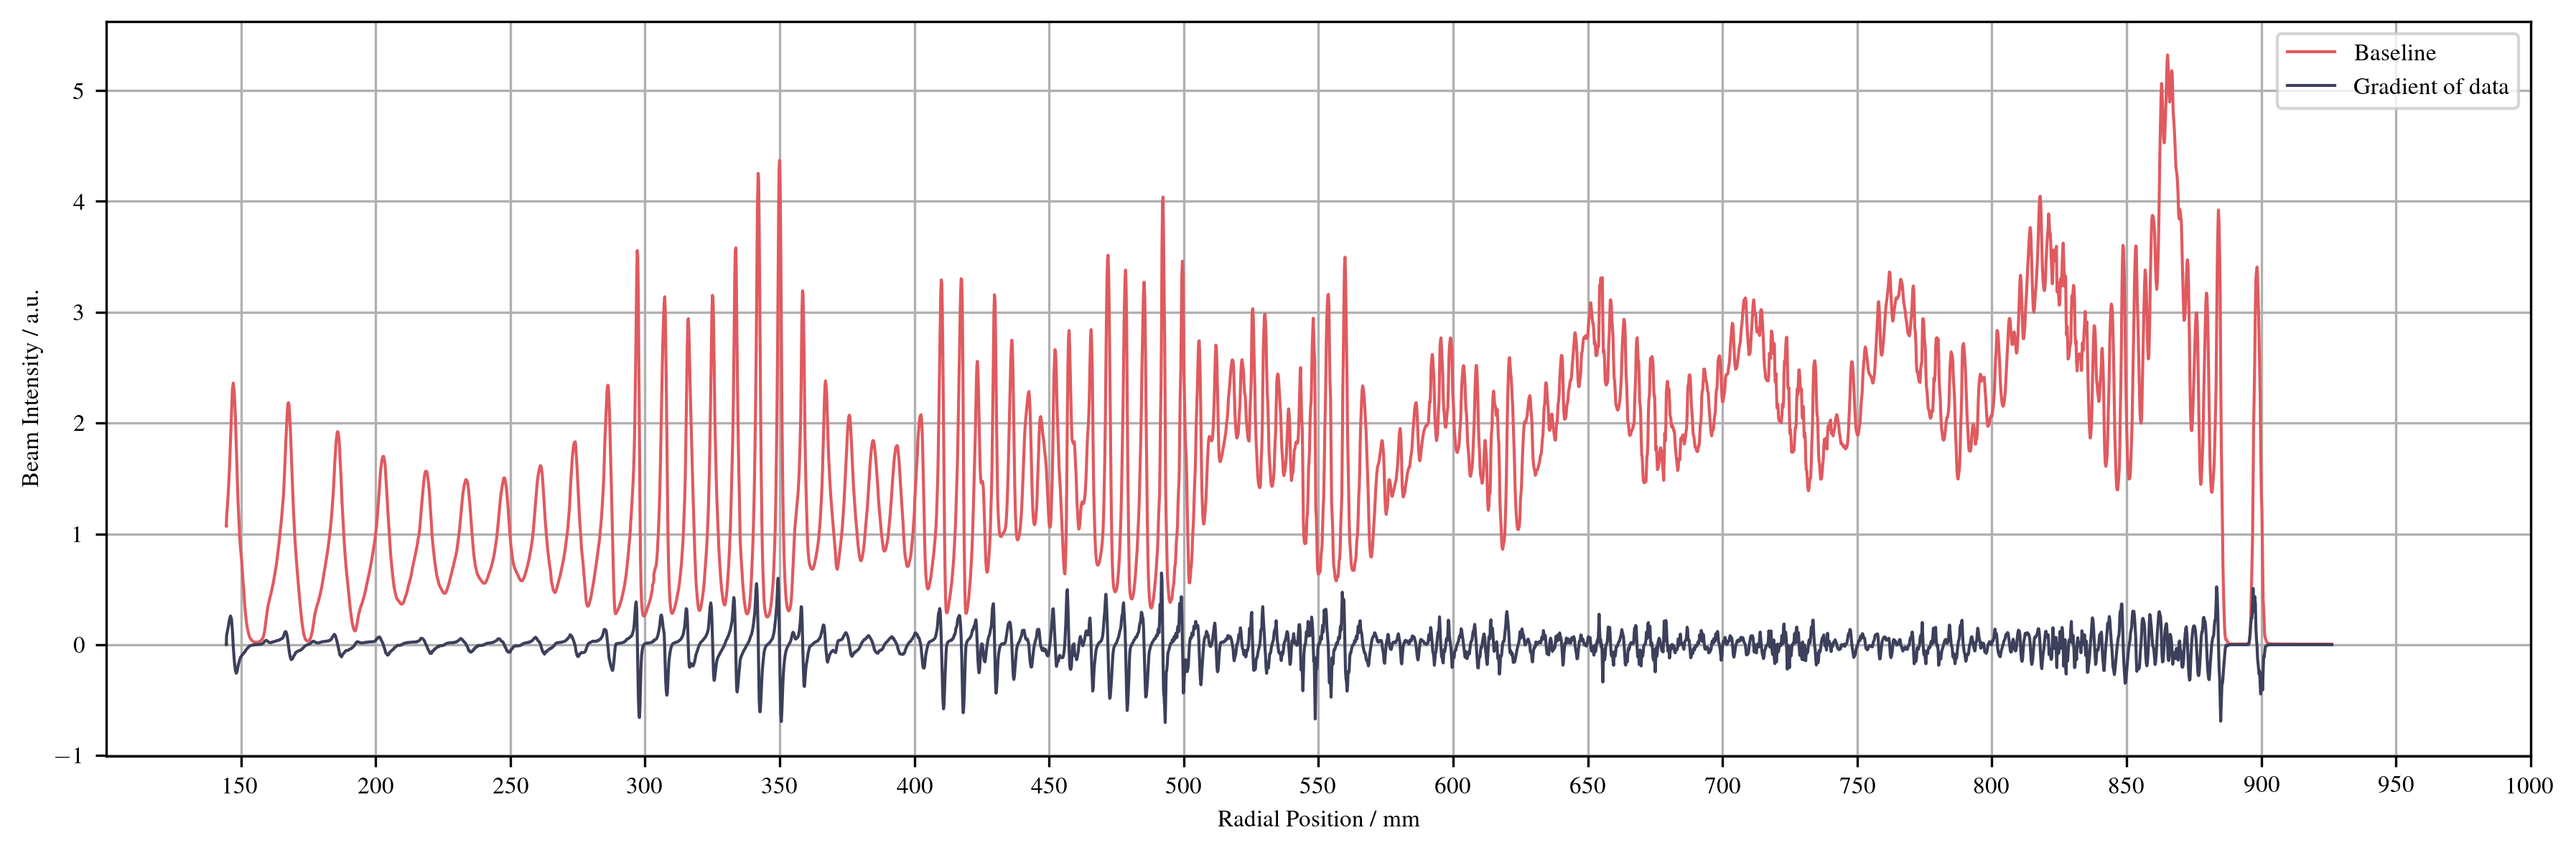

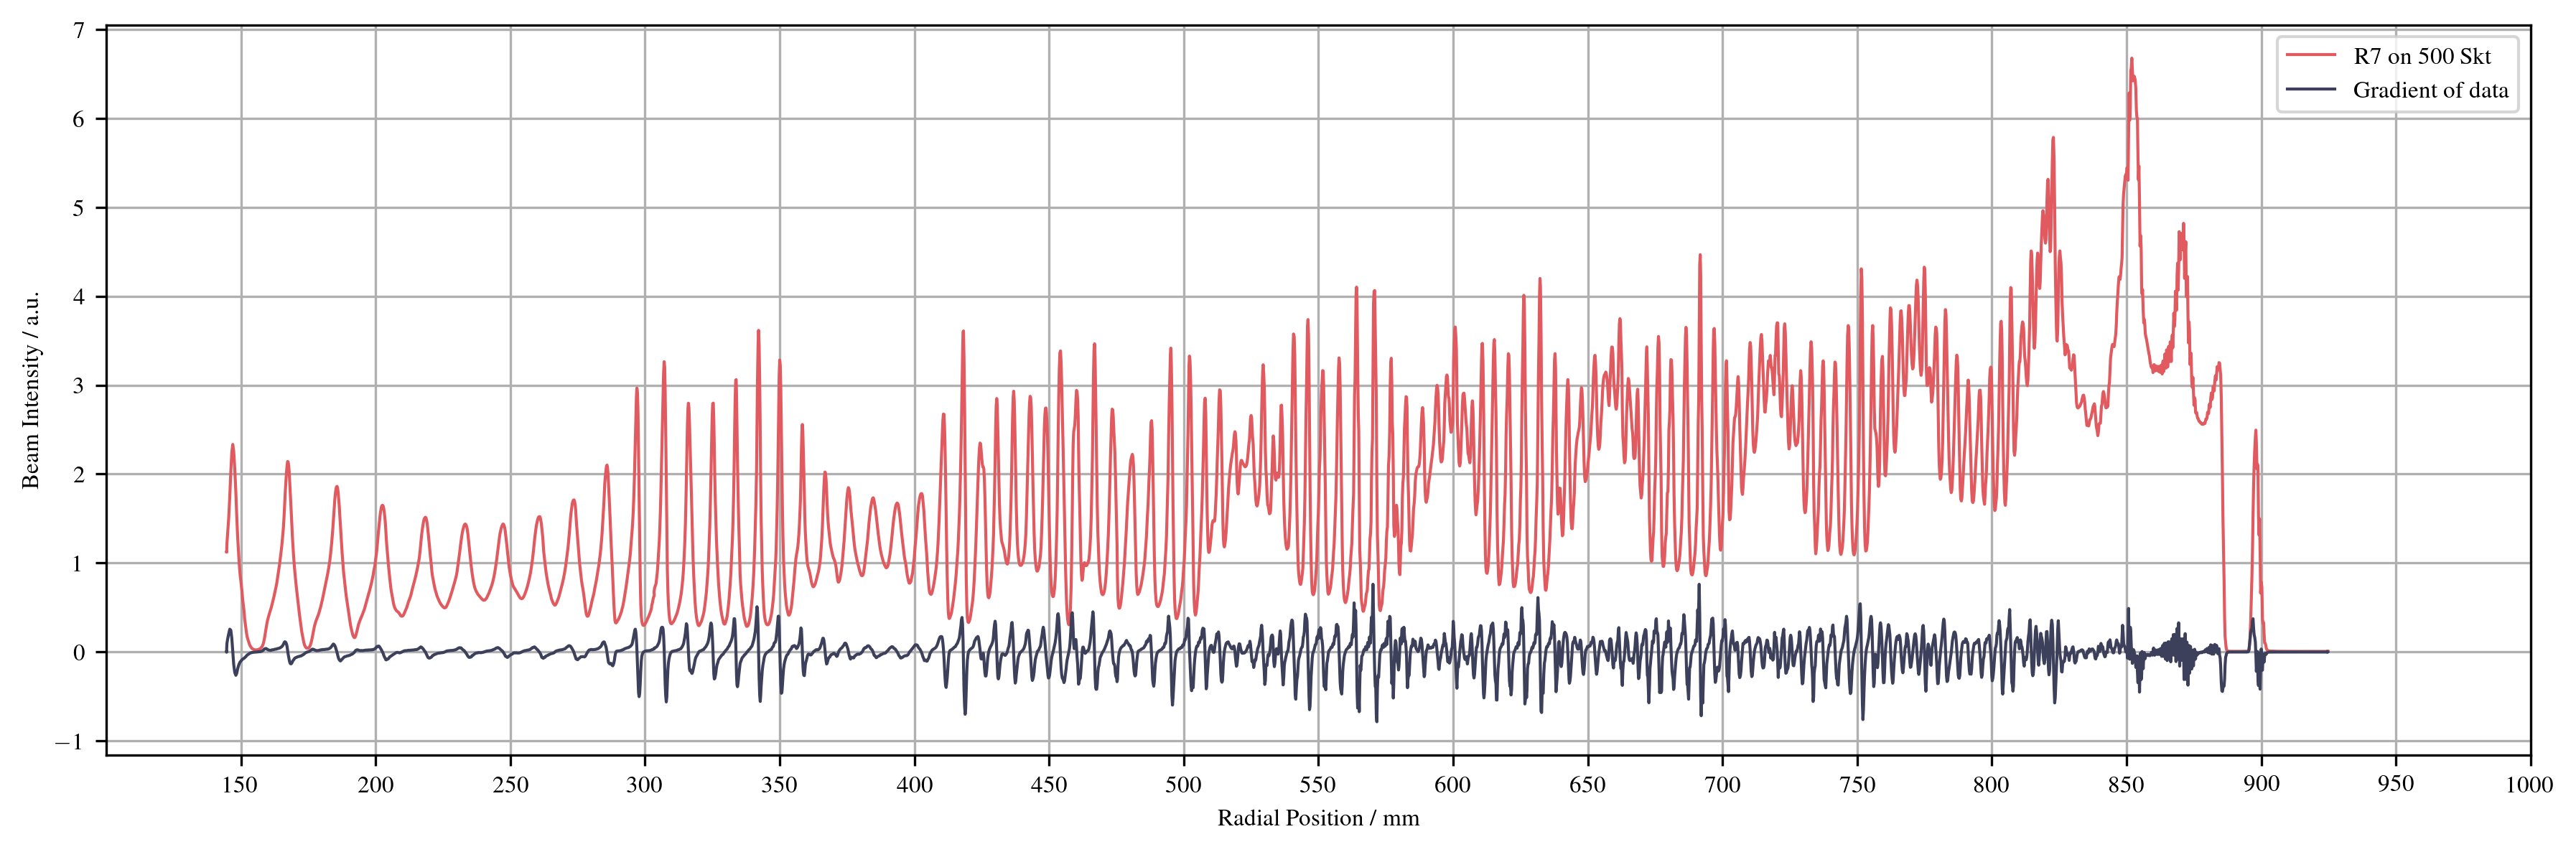

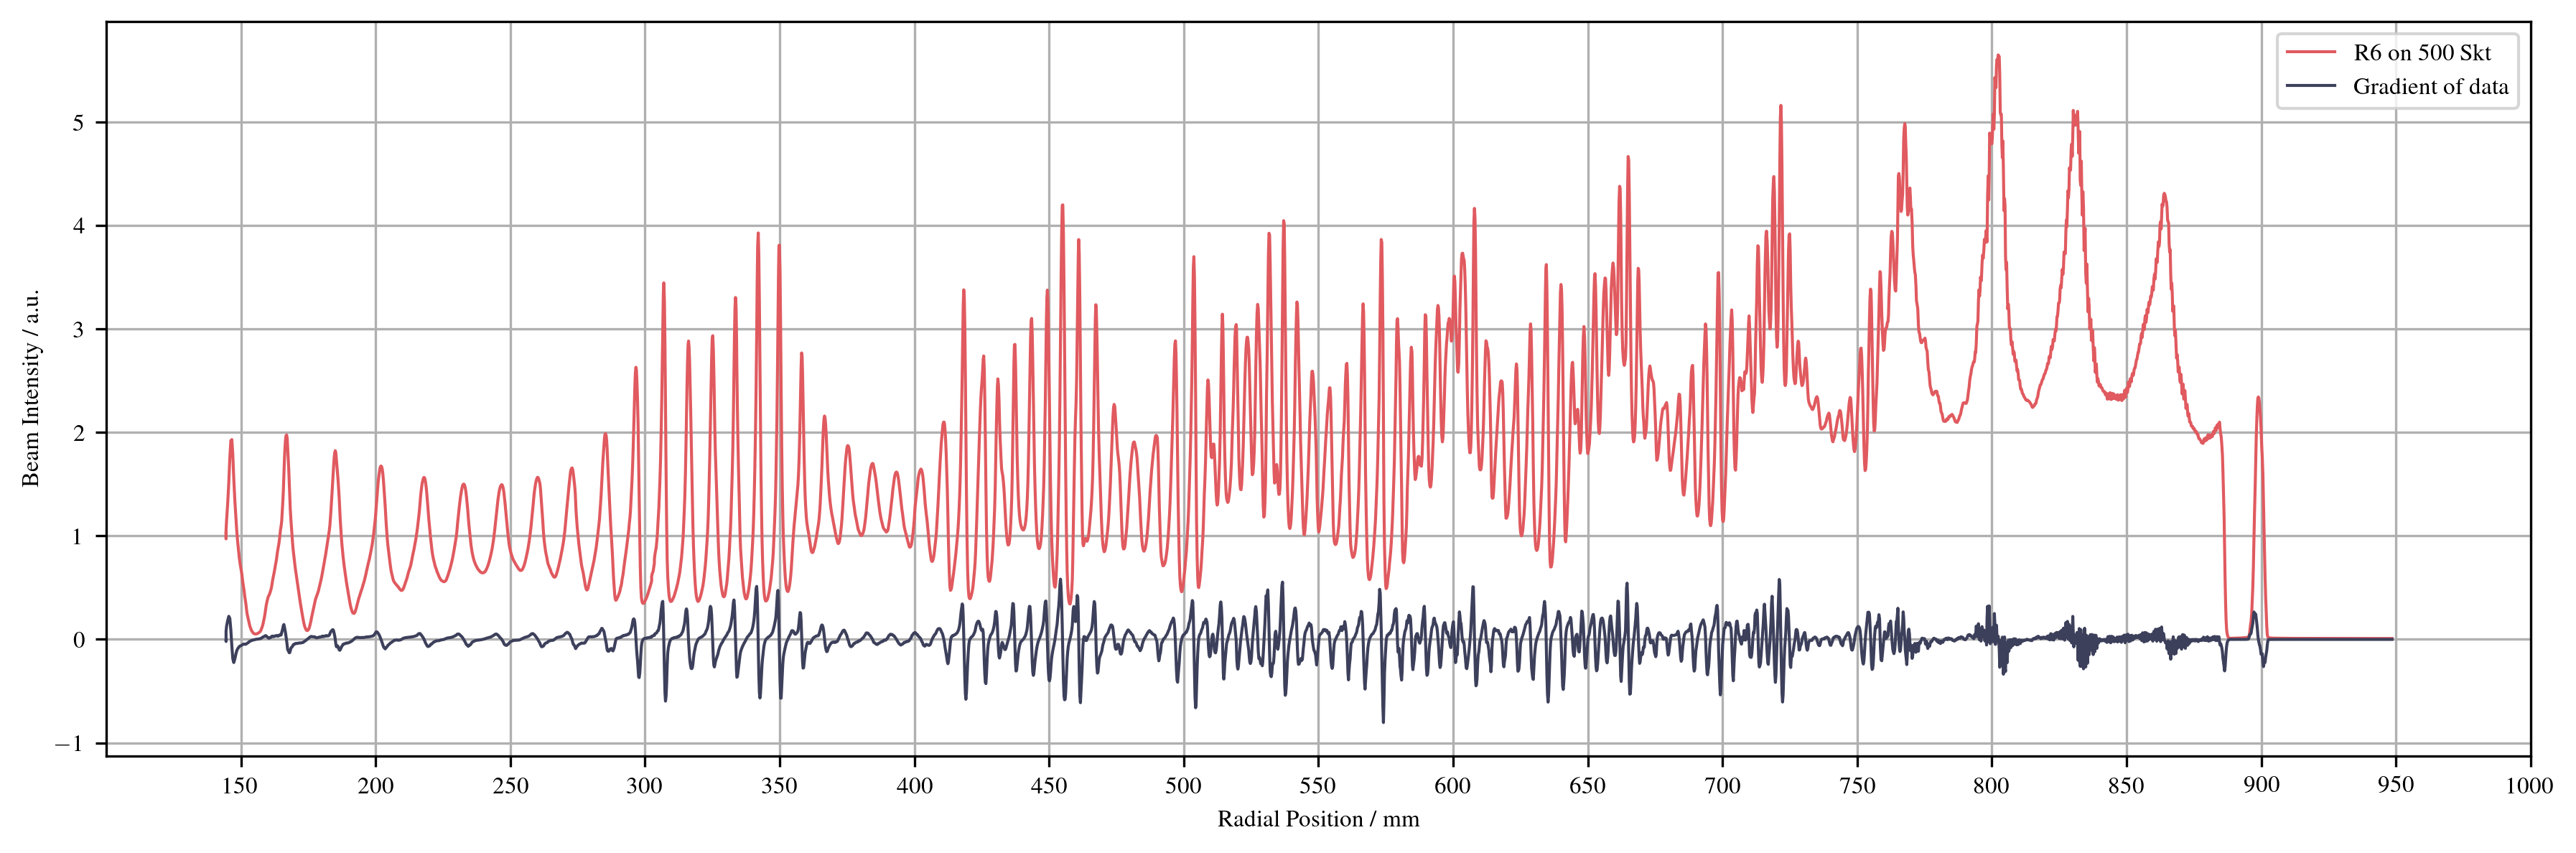

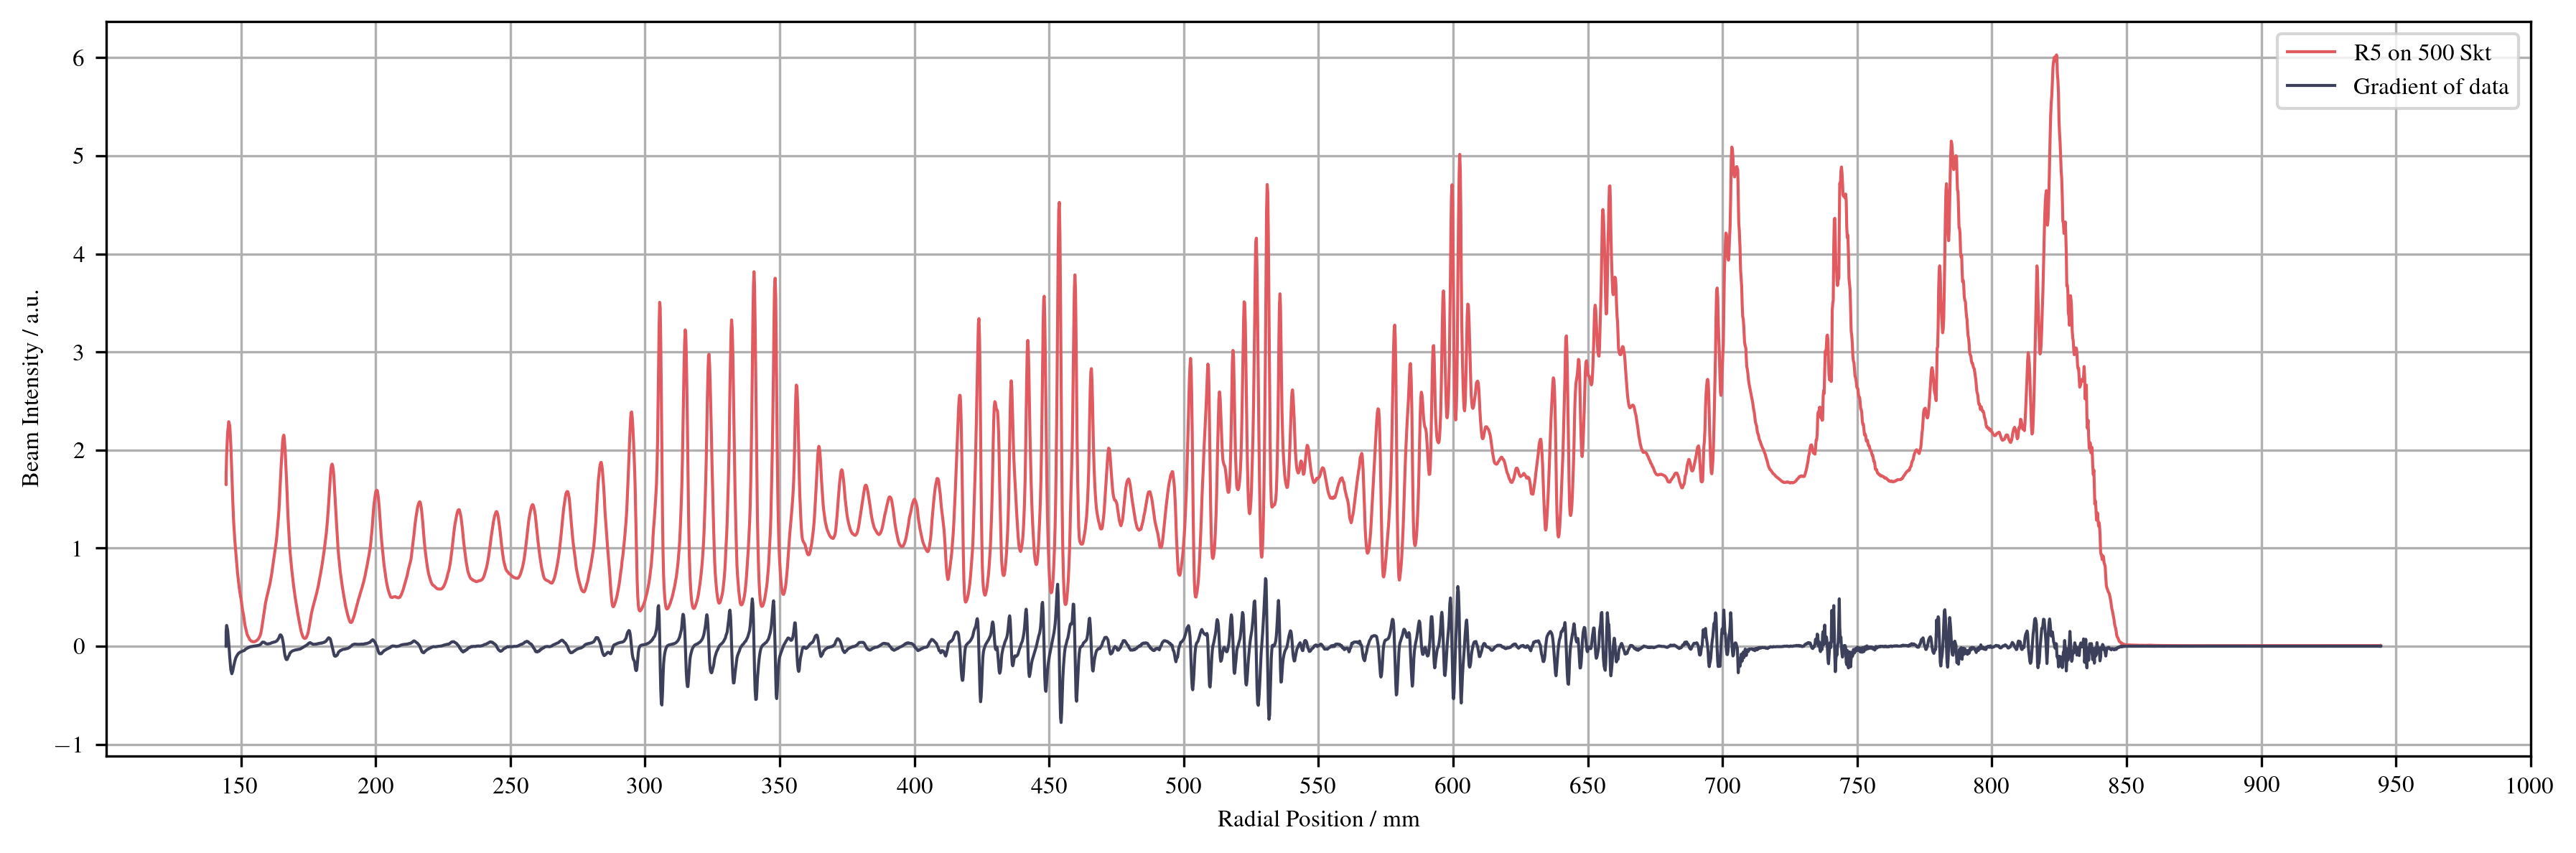

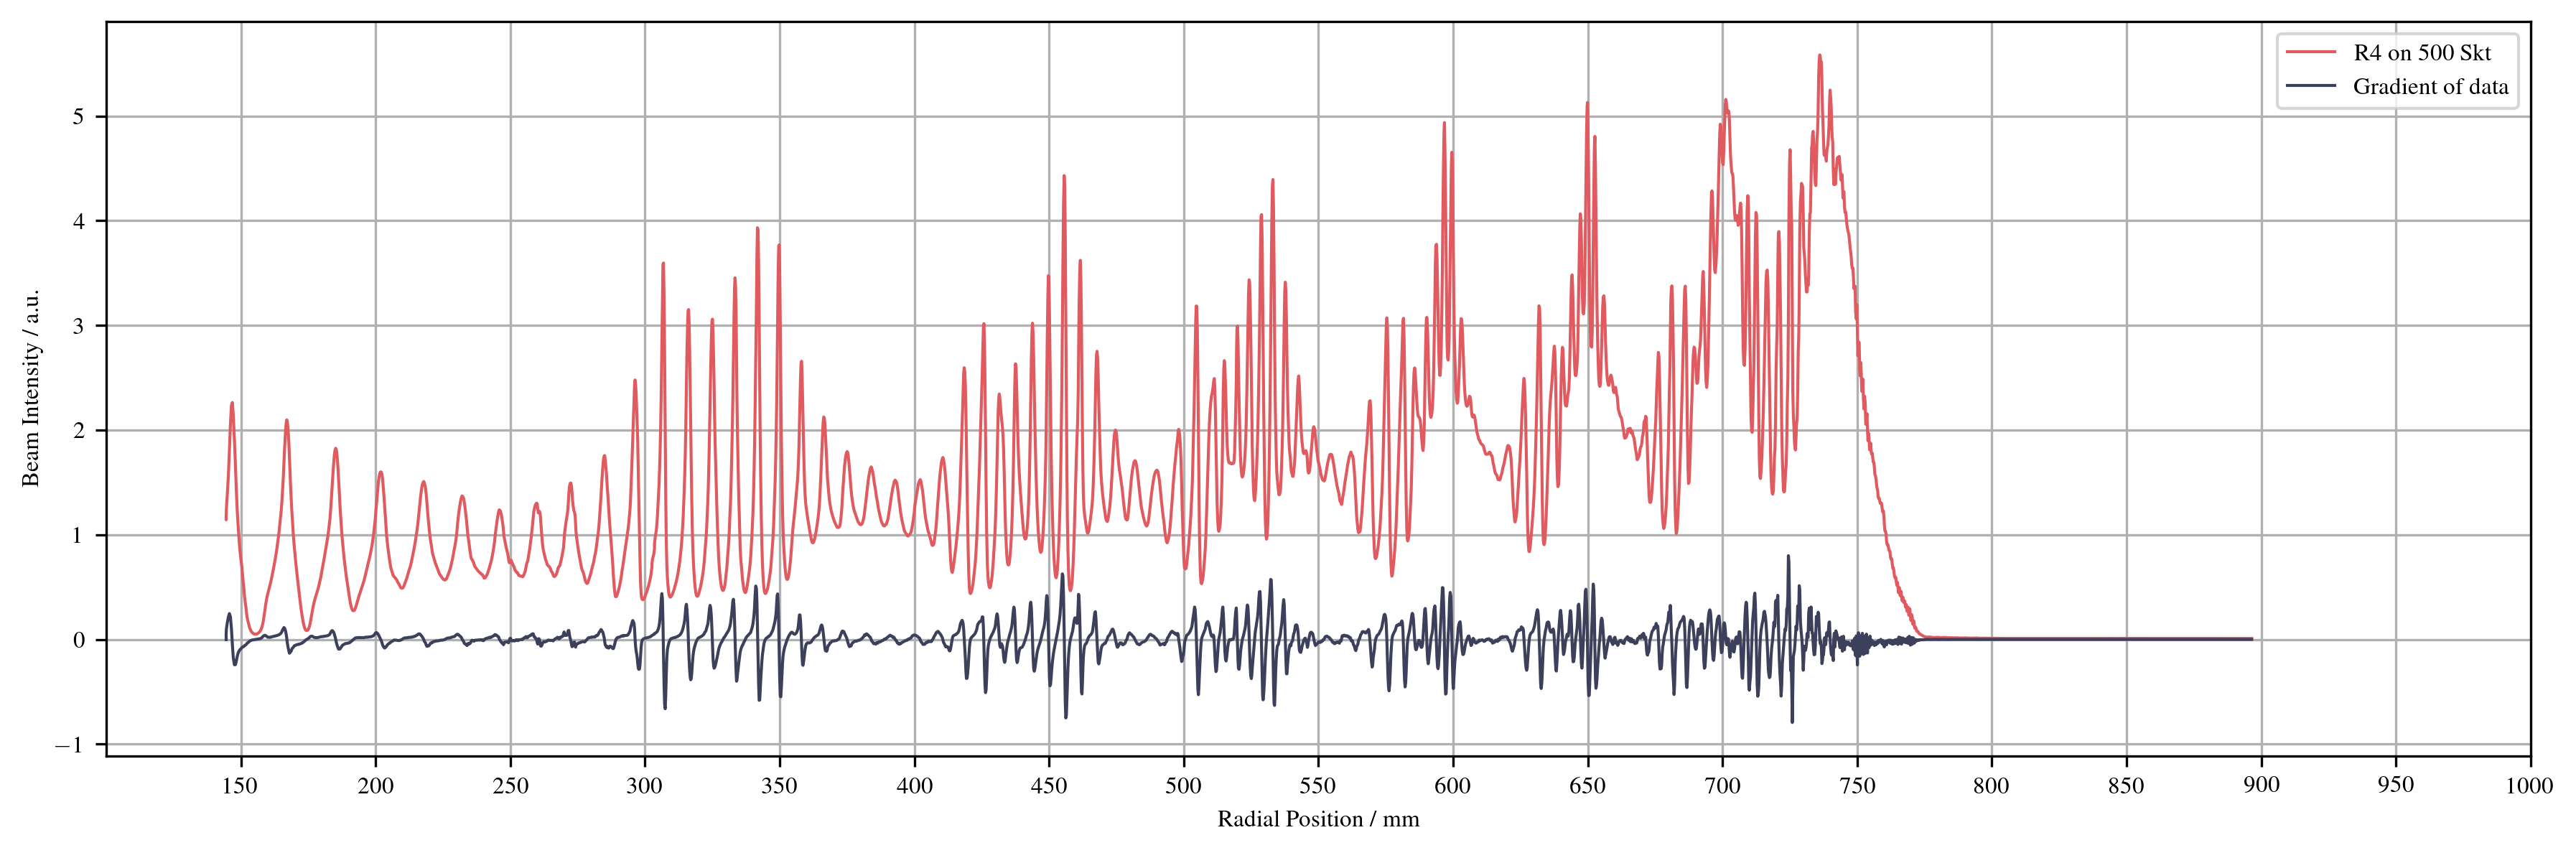

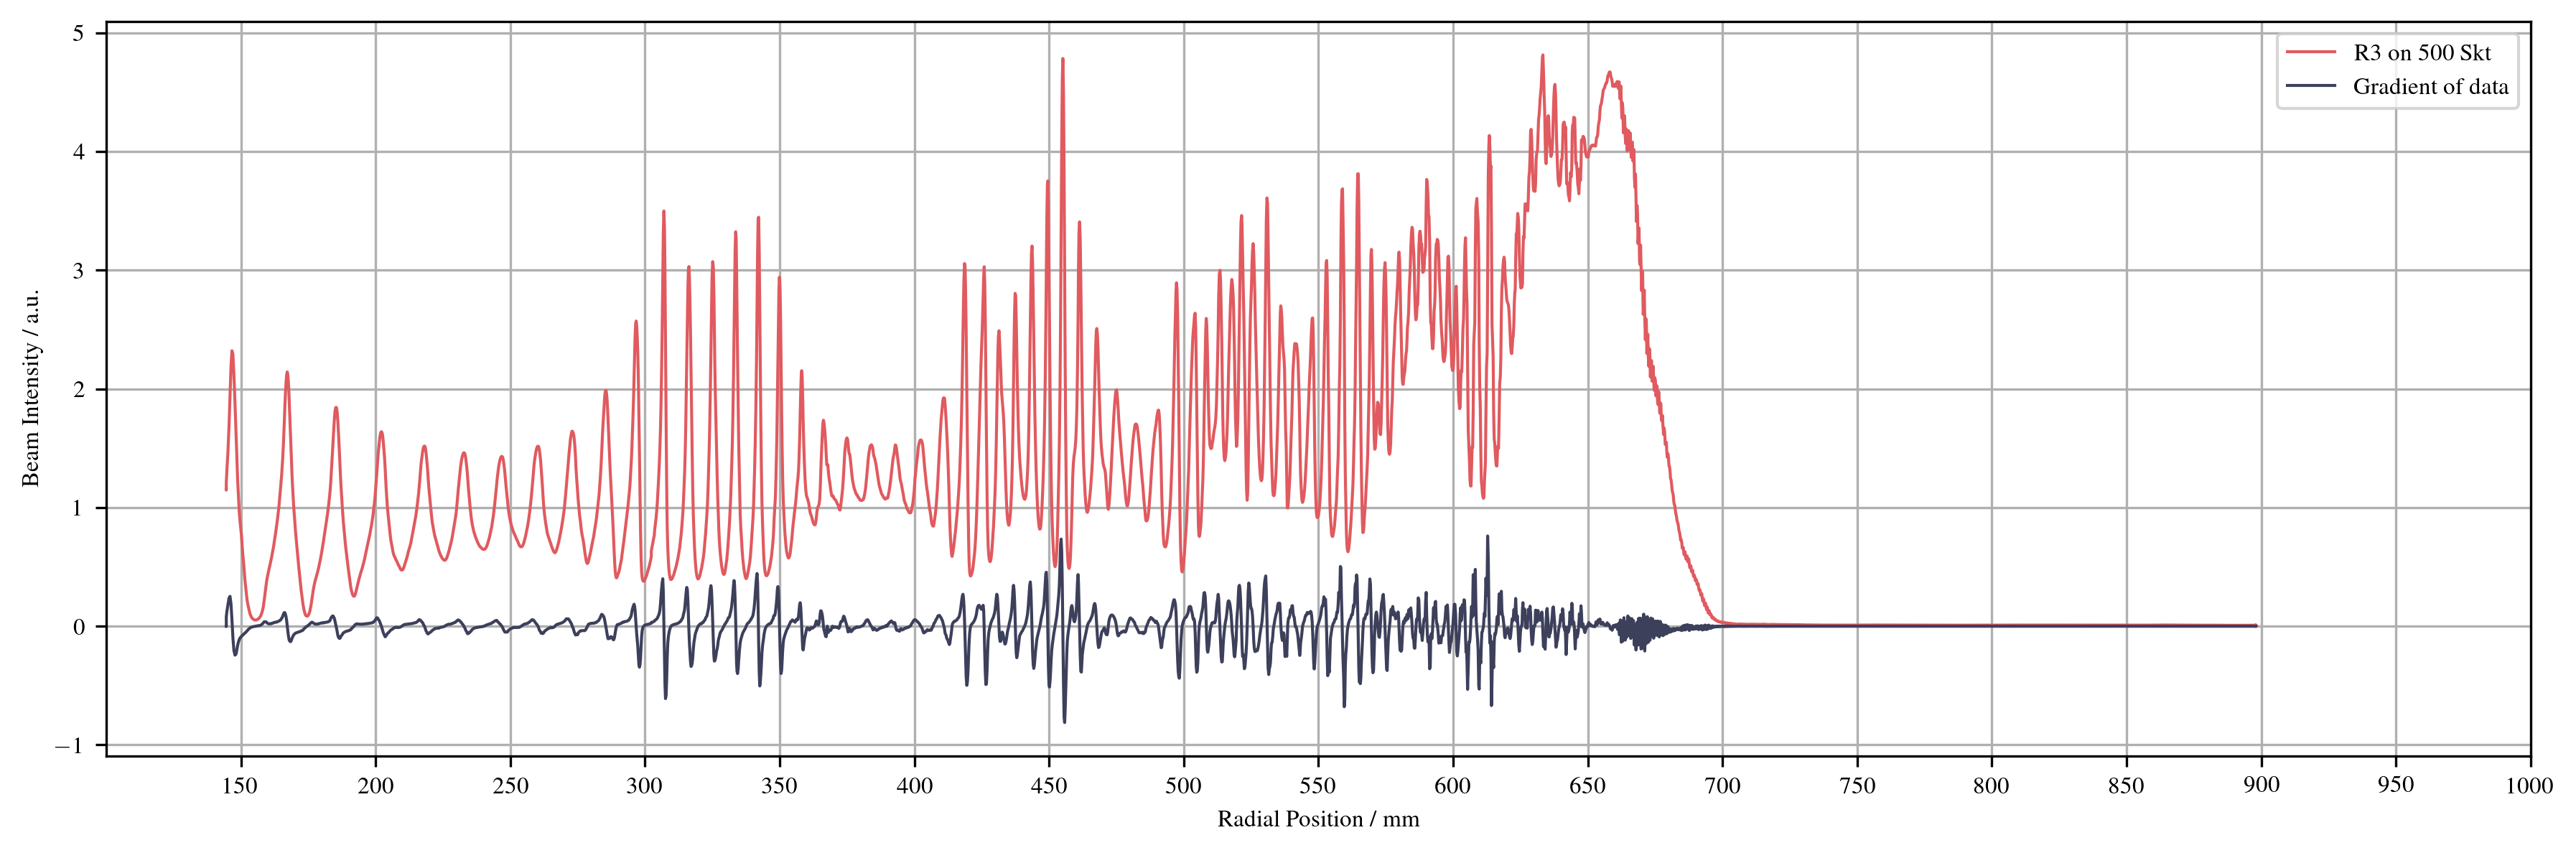

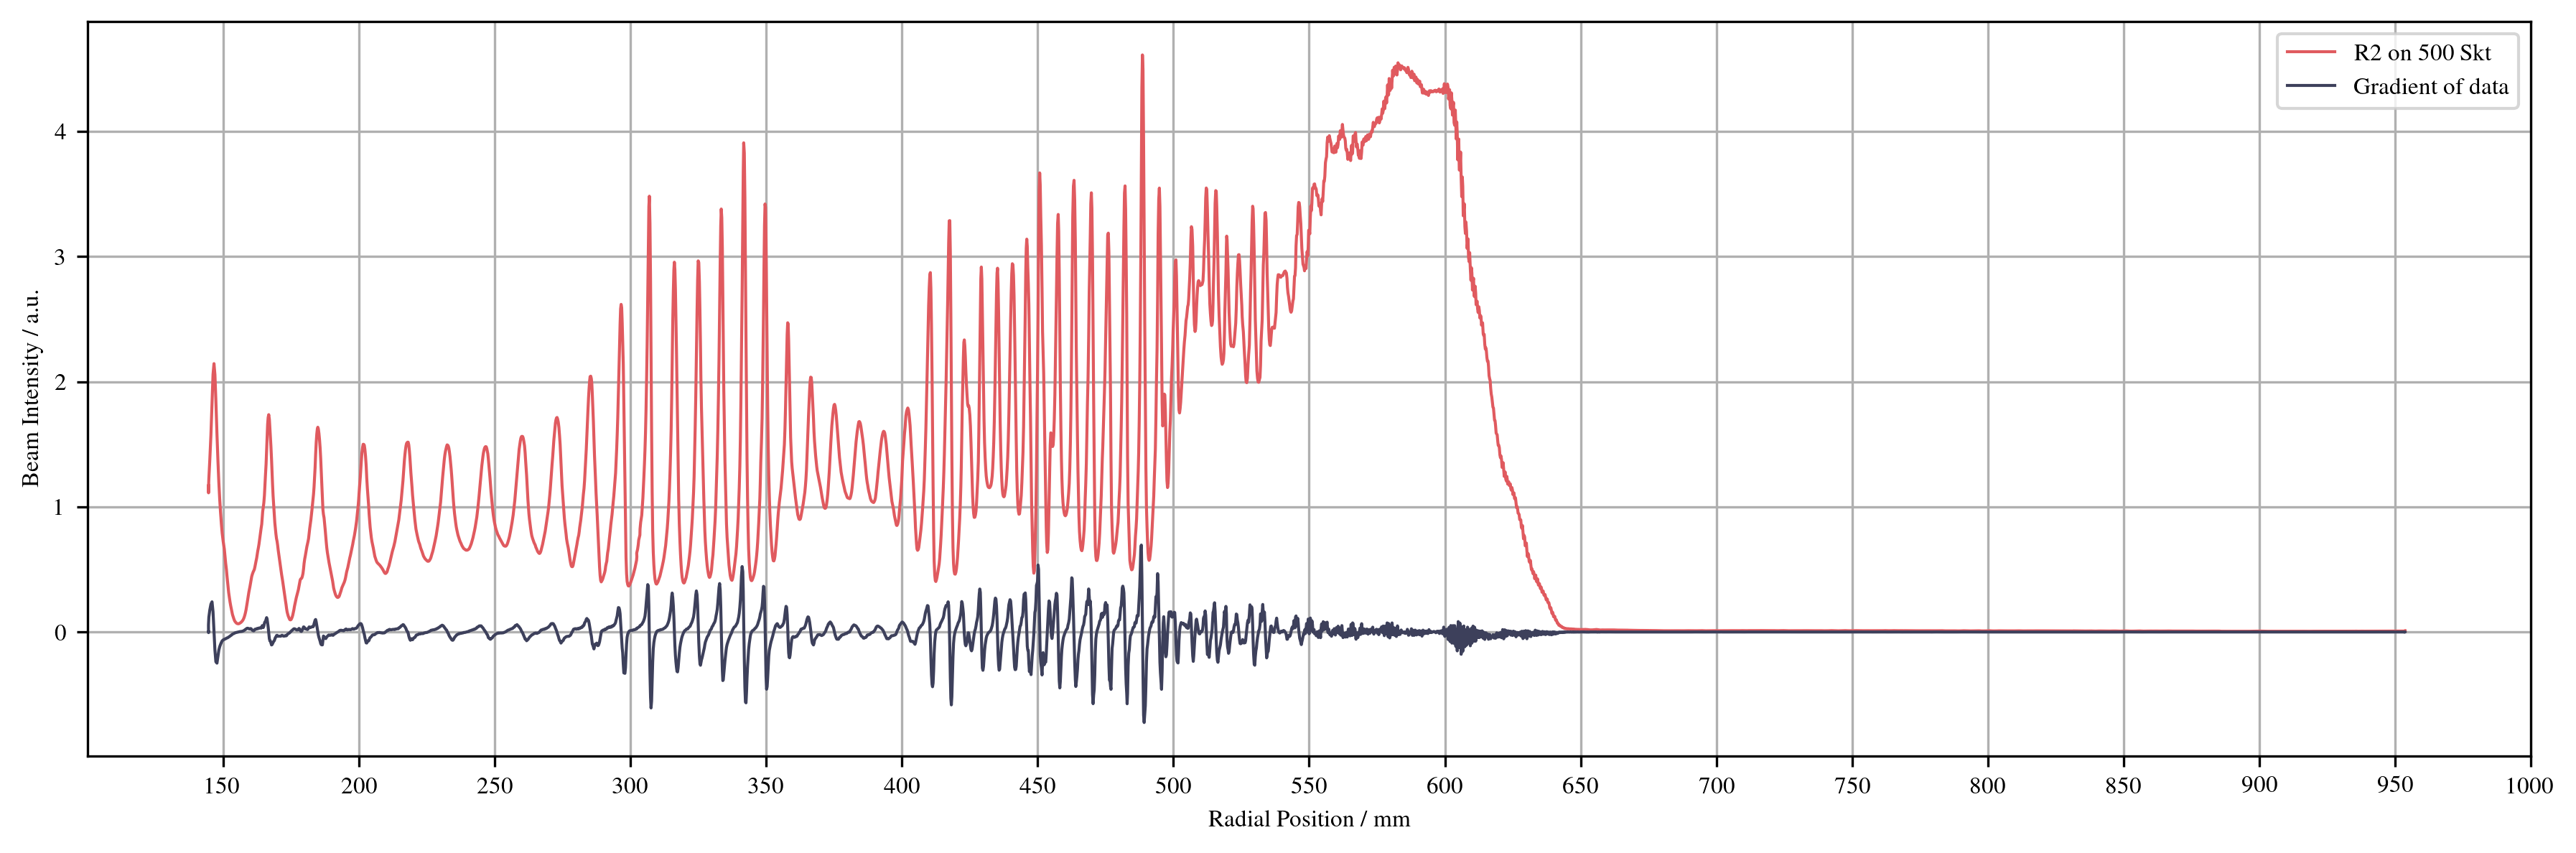

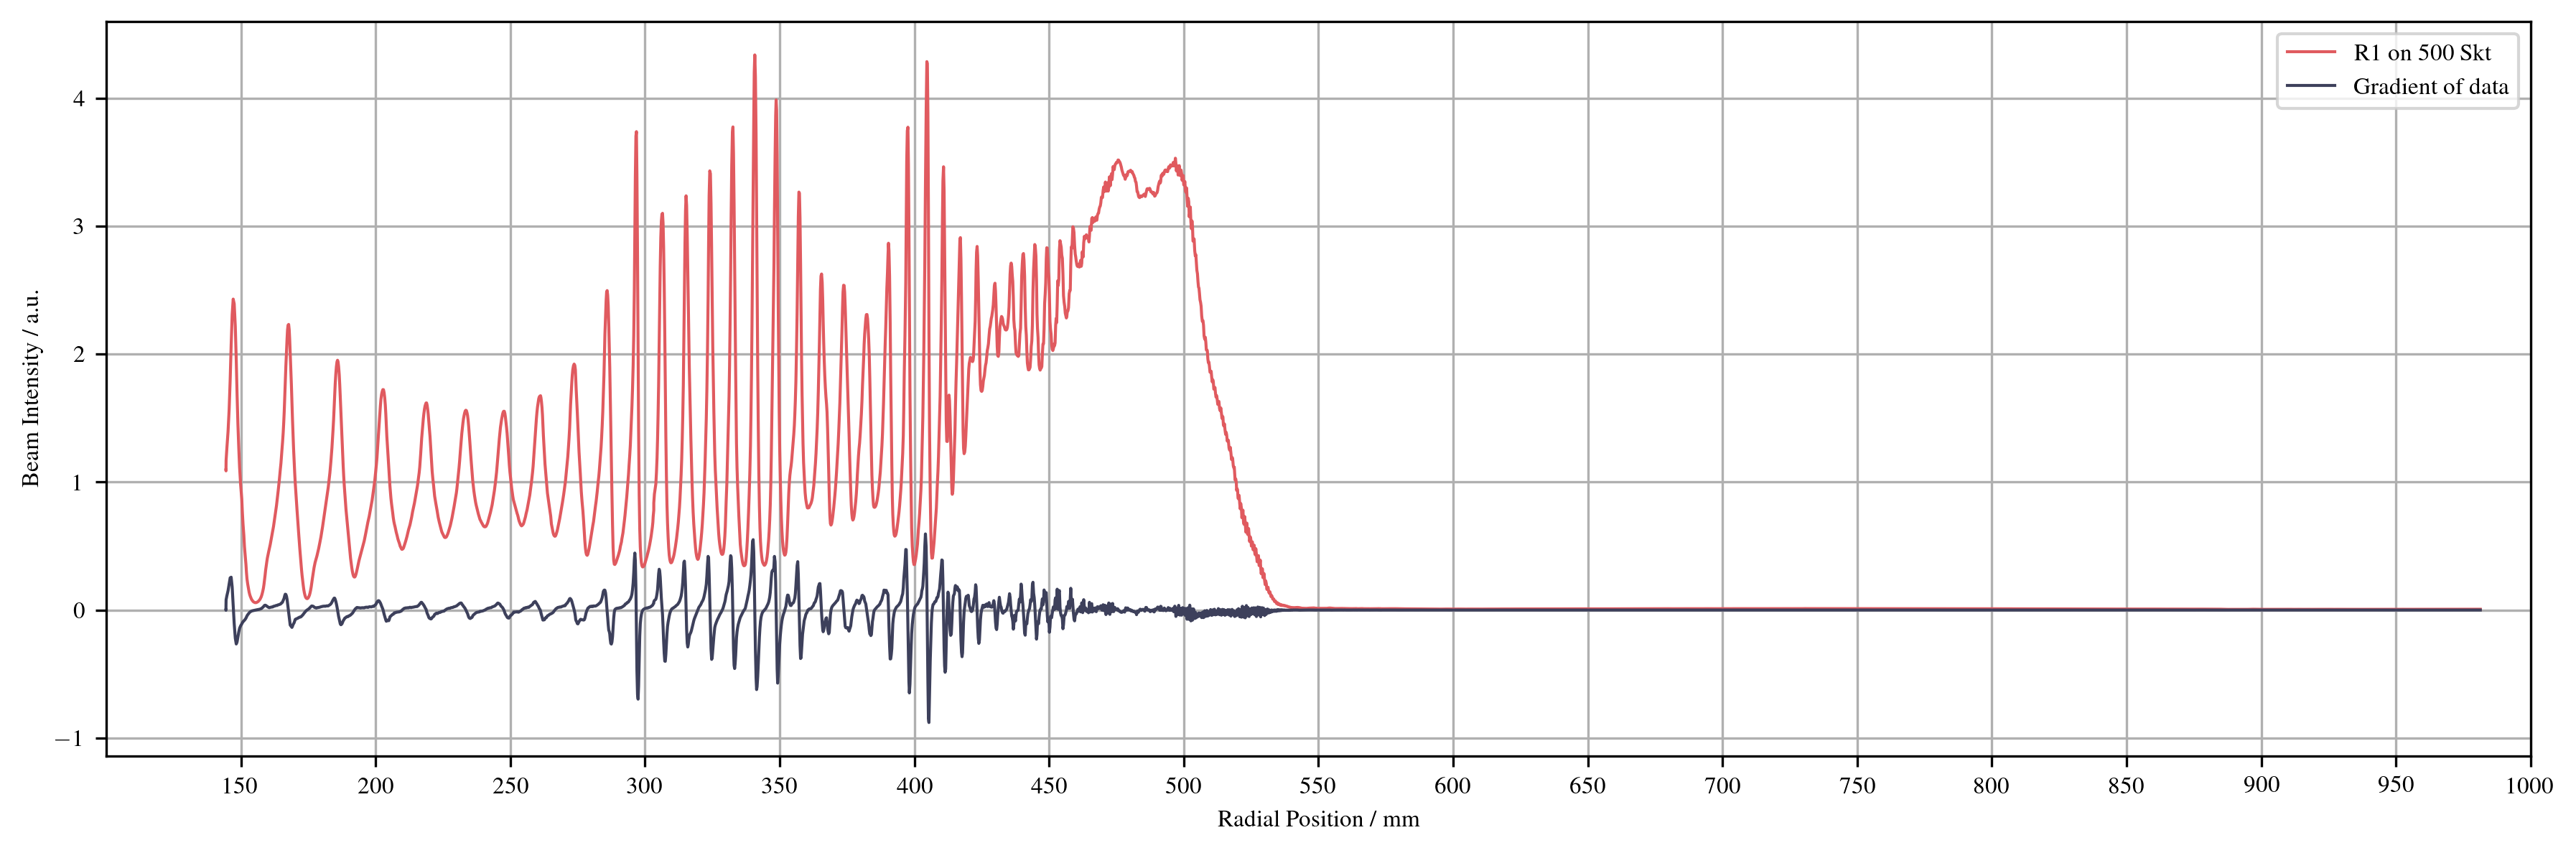

In [54]:
for file in os.listdir('./2026_KW16'):
    path = f'./2026_KW16/{file}'
    if os.path.isfile(path) == True and path != './2026_KW16/DS_1.txt':
        print(path)
        DichteschriebPlot(path,ds_info,peak_flag=False,grad_flag=True)
# DichteschriebPlot('./2026_KW12/260319/DS_Tab1_Z2.txt', ds_info, peak_flag=True)

In [4]:
def Dichteschrieb_stack(ds_info):
    
    plt.figure(figsize=(10,6), dpi=300)
    for key in ds_info.keys():
        print(key)
        i = int(key.split('.')[-2].split('_')[-1])
        print(i)
        df = pd.read_csv(key, skiprows=8, delimiter='\t', decimal=",")
        if (i == 2):
            plt.plot(df['Real.1']*100, df['Real'], color='black', lw=1, zorder=2, label=f'{key}')
        else:
            plt.plot(df['Real.1']*100, df['Real']+(3.5*(i-2)), color=color_schemes['c_rainbow'][i-3], lw=1, zorder=2, label=f'{ds_info[key]}')
            
    plt.legend(loc=1)
    plt.xlabel('Radial Position / mm')
    plt.ylabel('Intensity + Offset / a.u.')
    plt.tight_layout()
    plt.savefig('Korrekturspulen.pdf', dpi=300, transparent=False)

./2026_KW16/DS_2.txt
2
./2026_KW16/DS_3.txt
3
./2026_KW16/DS_4.txt
4
./2026_KW16/DS_5.txt
5
./2026_KW16/DS_6.txt
6
./2026_KW16/DS_7.txt
7
./2026_KW16/DS_8.txt
8
./2026_KW16/DS_9.txt
9
./2026_KW16/DS_10.txt
10


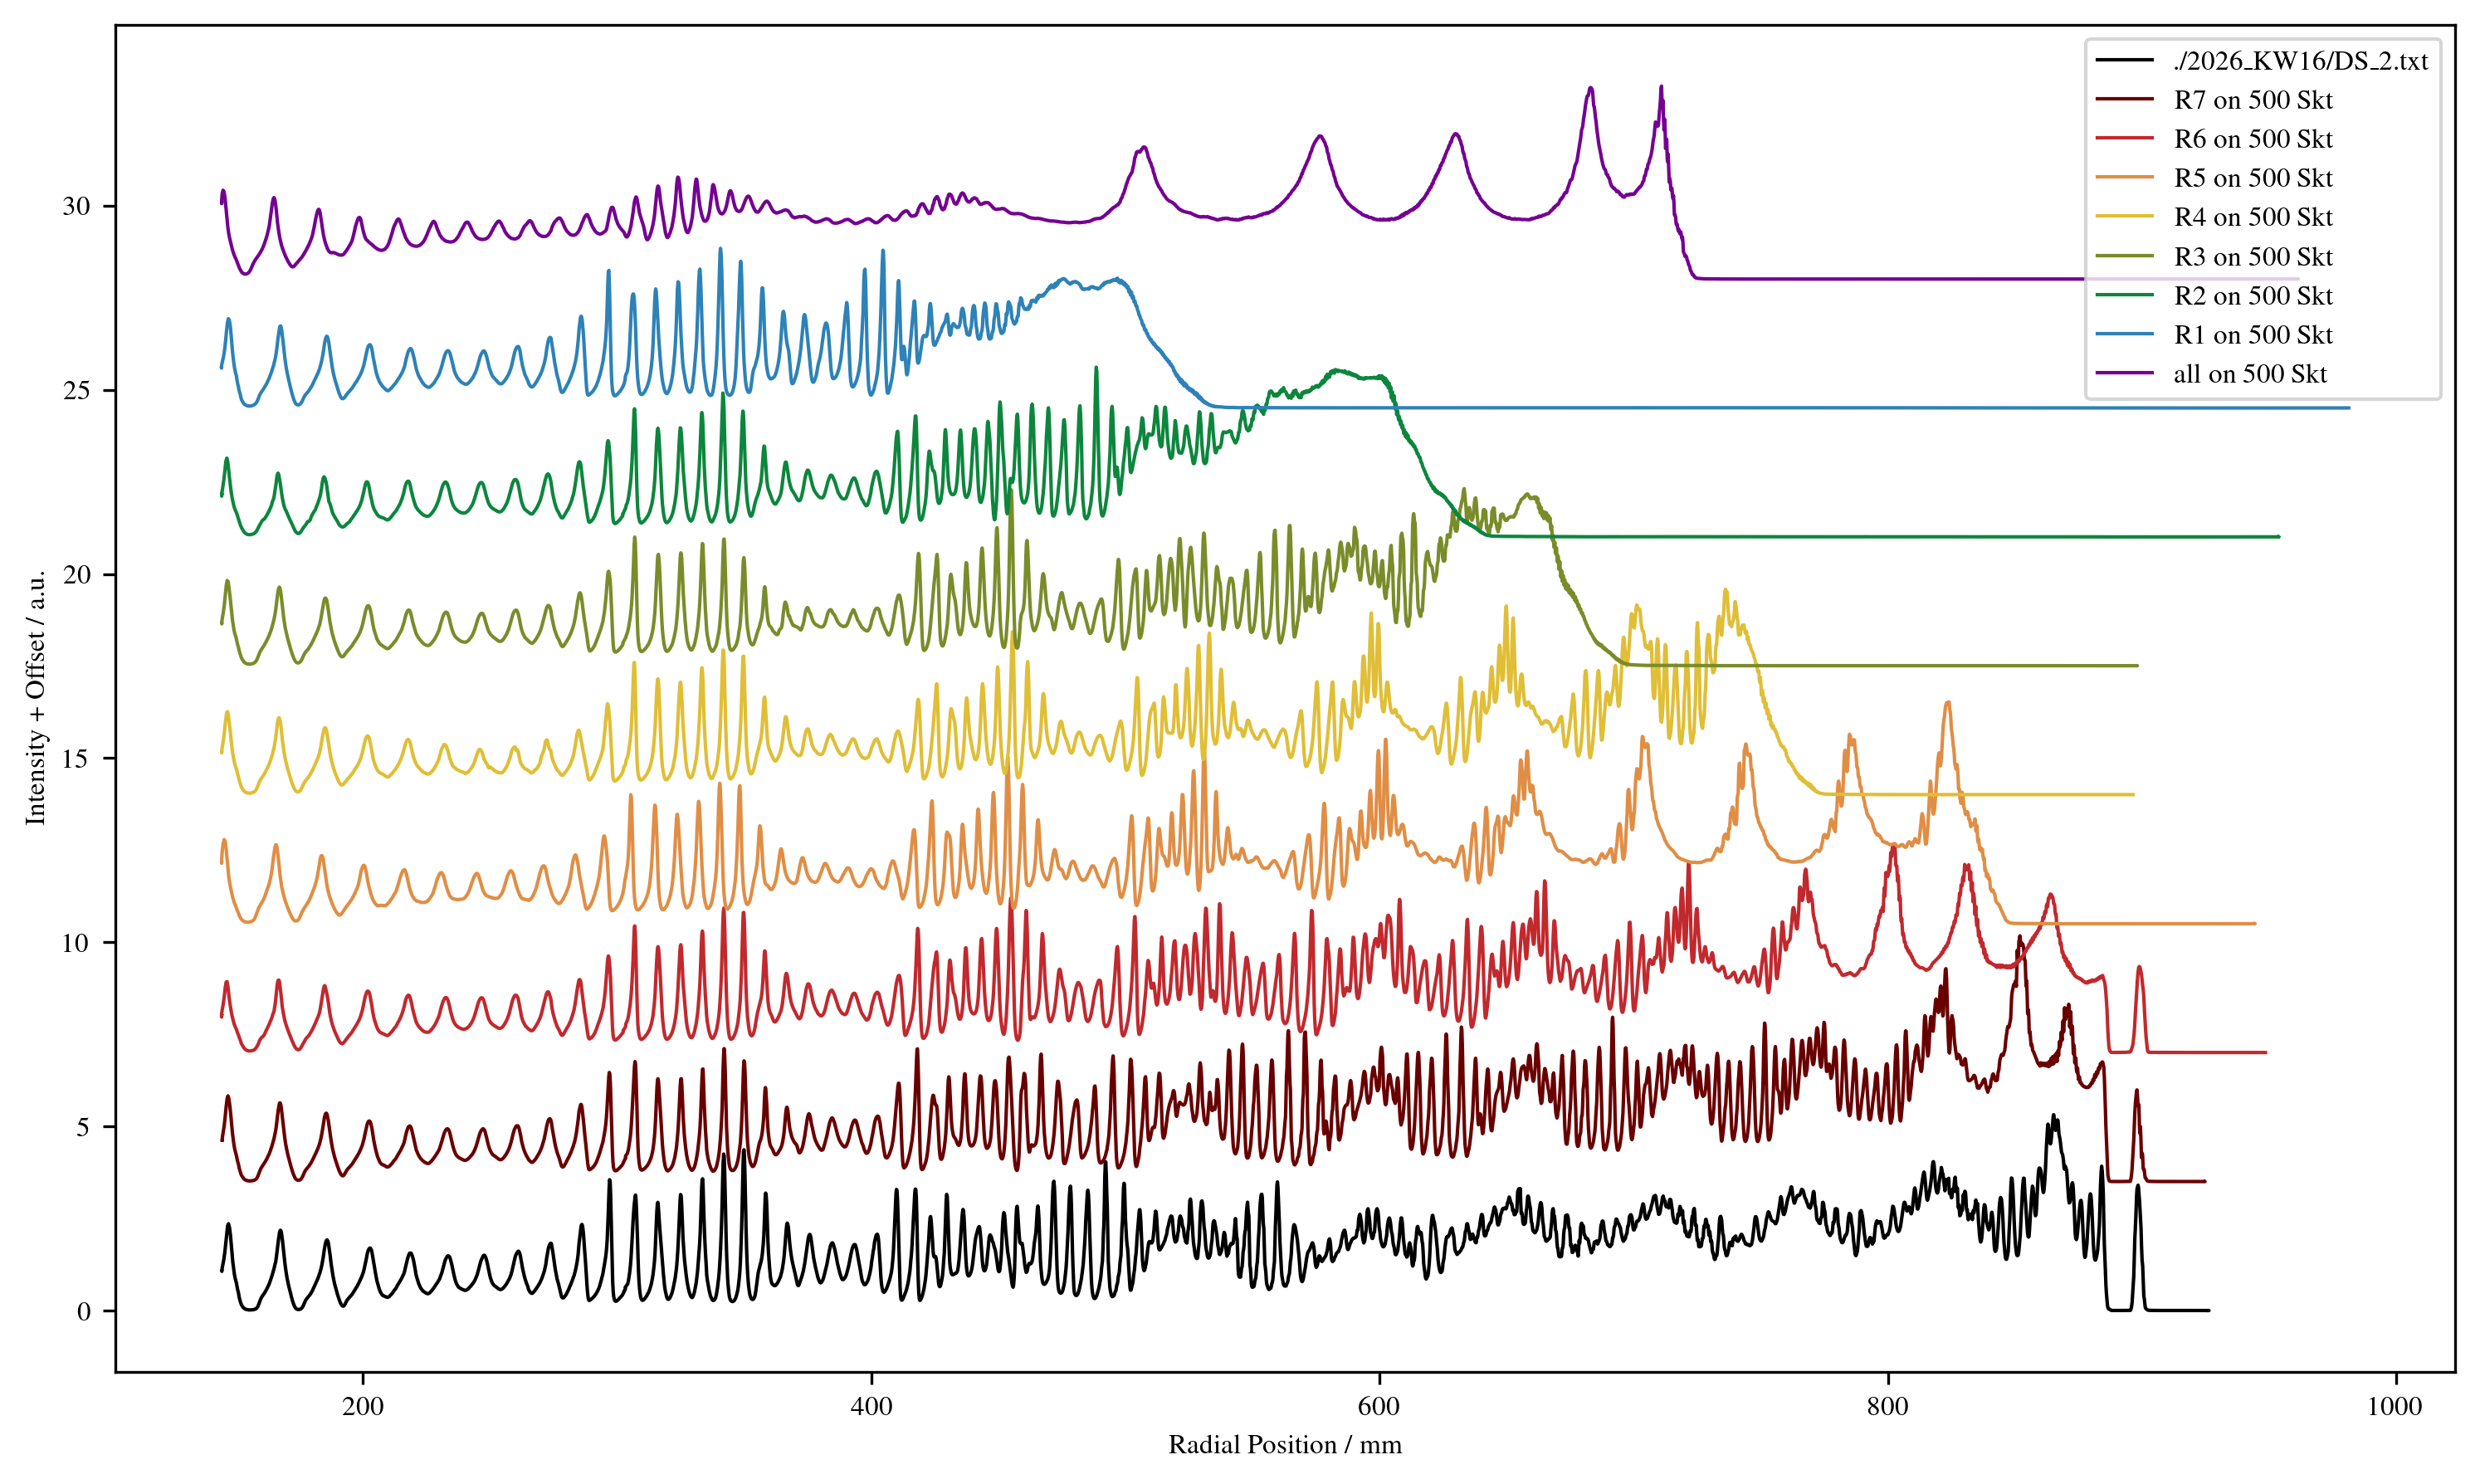

In [7]:
Dichteschrieb_stack(ds_info)

## Diffs

In [94]:
def diffs_of_DS_toBaseline(ds_info, ds_key:str):
    
    DPI = 250
    
    #BASELINE
    df_baseline = pd.read_csv("./2026_KW16/DS_2.txt", skiprows=8, delimiter='\t', decimal=",")
    baseline_x = df_baseline['Real.1']*100
    baseline_y = df_baseline['Real']
    
    df_comparison = pd.read_csv(ds_key, skiprows=8, delimiter='\t', decimal=",")
    comparison_x = df_comparison['Real.1']*100
    comparison_y = df_comparison['Real']

    comp_x_list = [round(float(elem),3) for elem in list(comparison_x)]
    comp_y_list = [round(float(elem),3) for elem in list(comparison_y)]
    base_x_list = [round(float(elem),3) for elem in list(baseline_x)]
    base_y_list = [round(float(elem),3) for elem in list(baseline_y)]
    
    comp_x_list, comp_y_list = zip(*sorted(zip(comp_x_list, comp_y_list)))
    base_x_list, base_y_list = zip(*sorted(zip(base_x_list, base_y_list)))
    
    len_dif = len(base_y_list)-len(comp_y_list)
    print(len_dif)
    if (len_dif < 0):
        comp_y_interp = np.interp(base_x_list,comp_x_list[:len_dif],comp_y_list[:len_dif])
    else:
        base_x_list = base_x_list[:-len_dif]
        base_y_list = base_y_list[:-len_dif]
        comp_y_interp = np.interp(base_x_list,comp_x_list,comp_y_list)
    fig, ax = plt.subplots(figsize=(10,4), dpi=DPI, nrows=2, sharex=True, height_ratios=[2,1])
    ax[0].plot(baseline_x, baseline_y, color=color_schemes['c_dark'][0],alpha=0.4, lw=1, zorder=2, label=f'Baseline (BL)')
    ax[0].plot(comp_x_list, comp_y_list, color=color_schemes['c_five'][1], lw=1, zorder=3, label=f'{ds_info[ds_key]} (DS)')
    
    ax[1].plot(base_x_list, base_y_list-comp_y_interp, color=color_schemes['c_five'][2], lw=1, zorder=2, label=r'$\Delta I = I_{\mathrm{BL}} - I_{\mathrm{DS}}$')
    
    ax[0].legend(loc=2)
    ax[1].legend(loc=2)
    
    ax[0].set_ylabel(r'Intensity $I$ / a.u.')
    ax[1].set_ylabel(r'$\Delta I$ / a.u.')
    
    ax[1].set_ylim(-6,6)
    ax[1].set_yticks([-6,-4,-2,0,2,4,6],[-6,-4,-2,0,2,4,6])
    ax[1].grid()
    
    plt.xlabel('Radial Position / mm')
    
    plt.tight_layout()
    plt.savefig(f'./Dichteschriebe_python/{ds_key.split('/')[2].split('.')[0]}_baselineDiff.pdf', dpi=300)
    return 9

-104
-56
4
-28
340
204
-312
-48


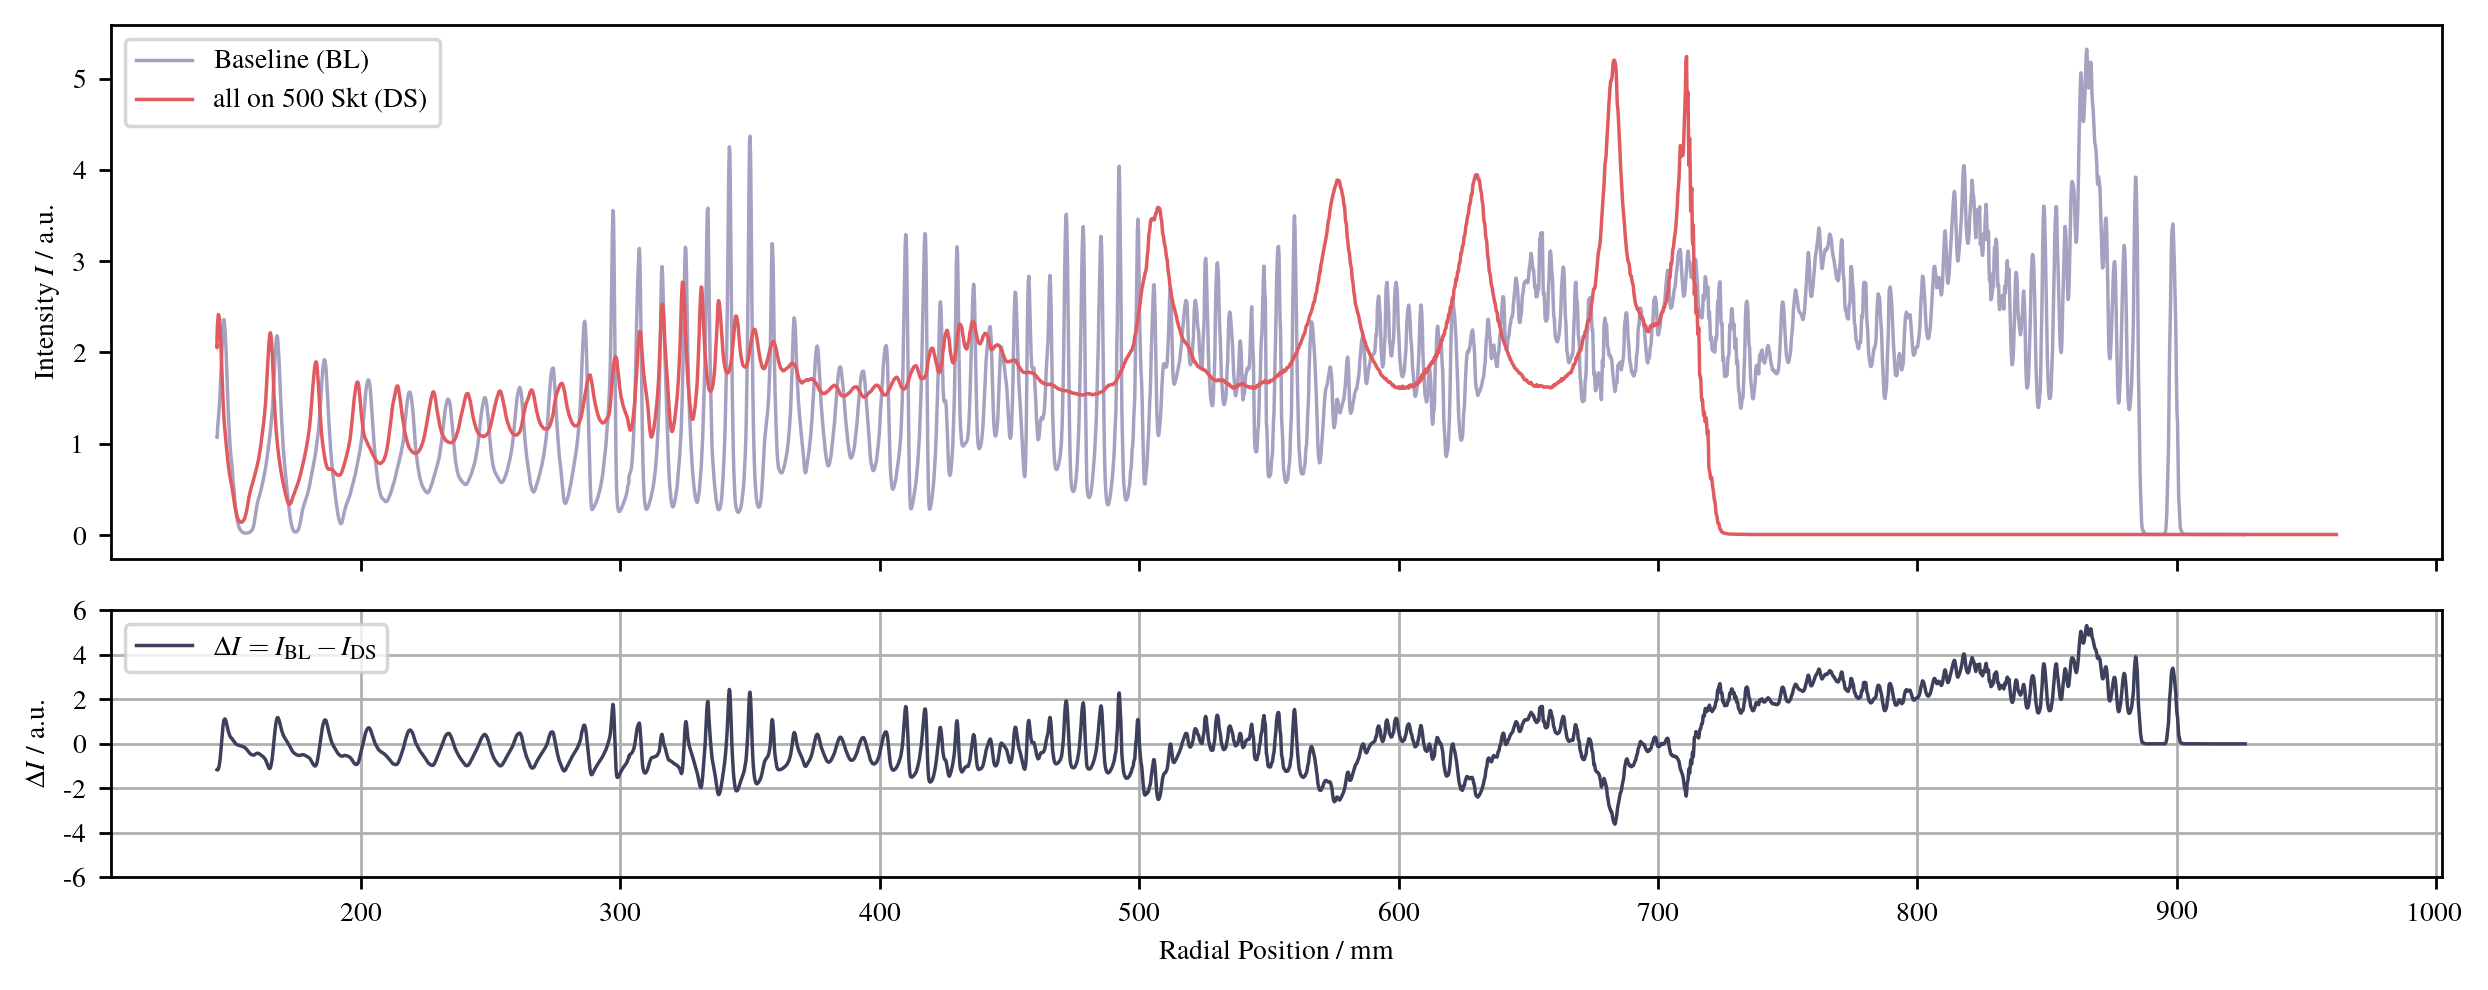

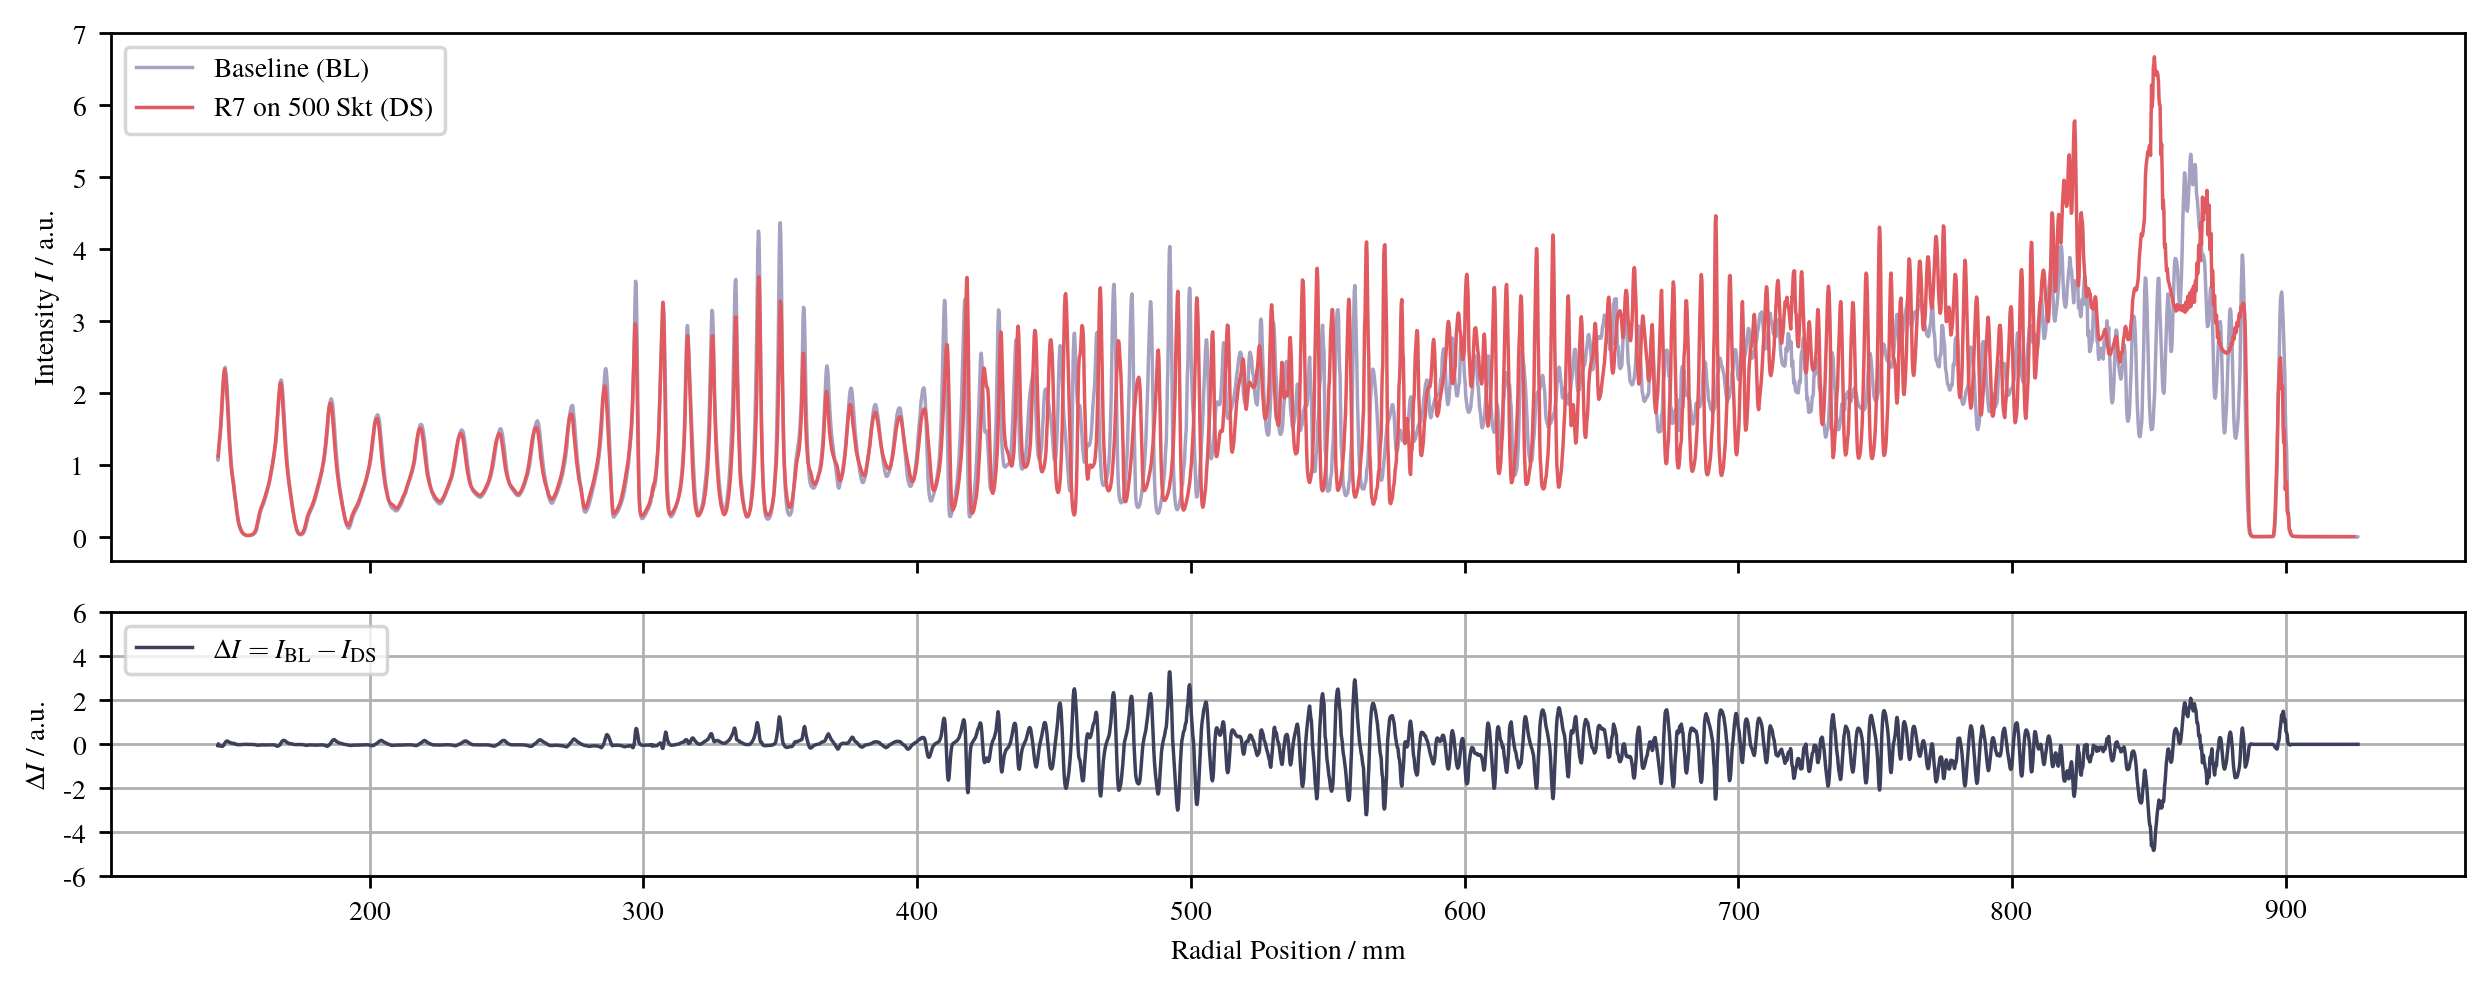

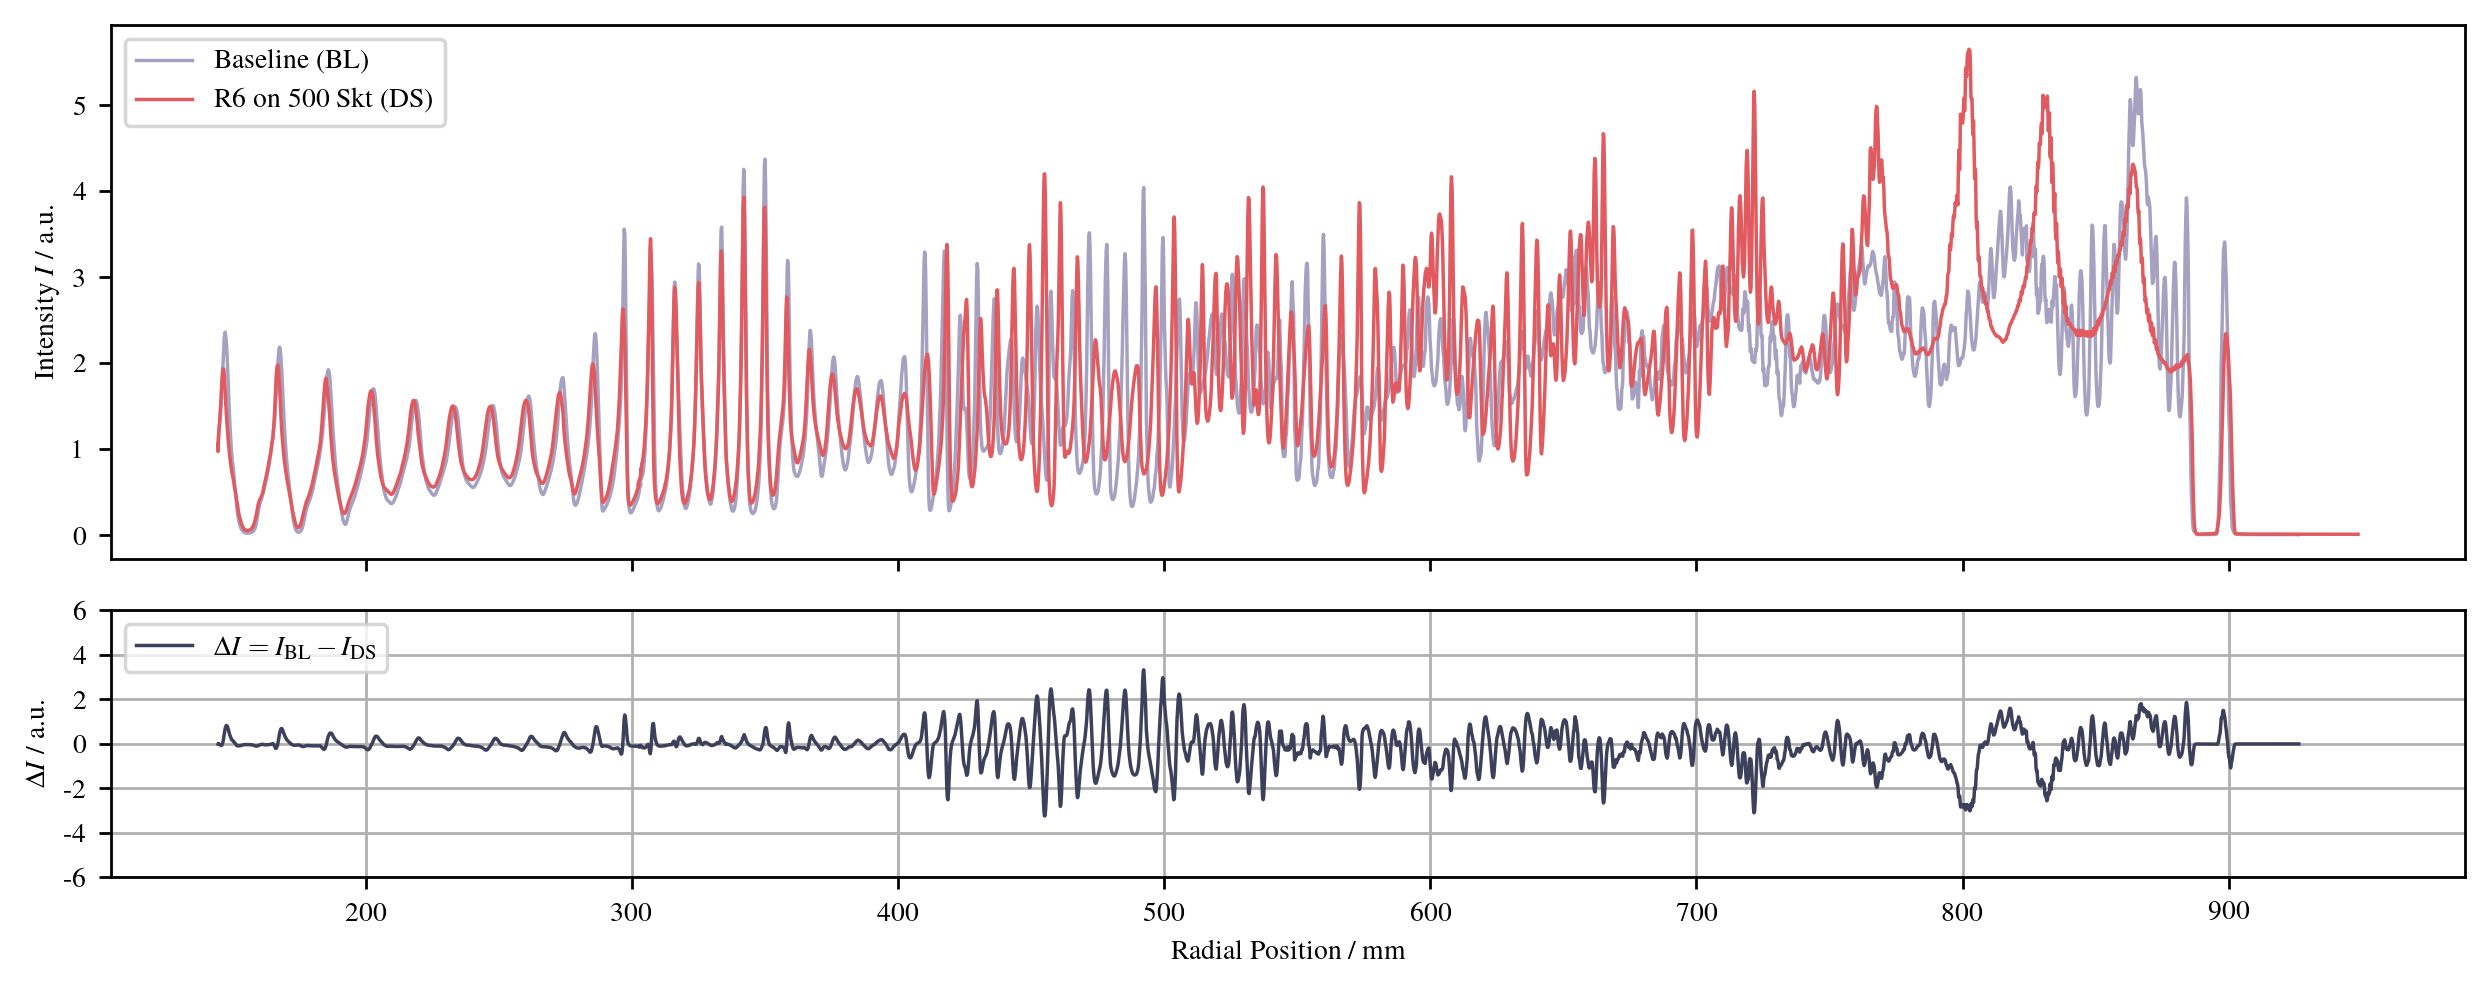

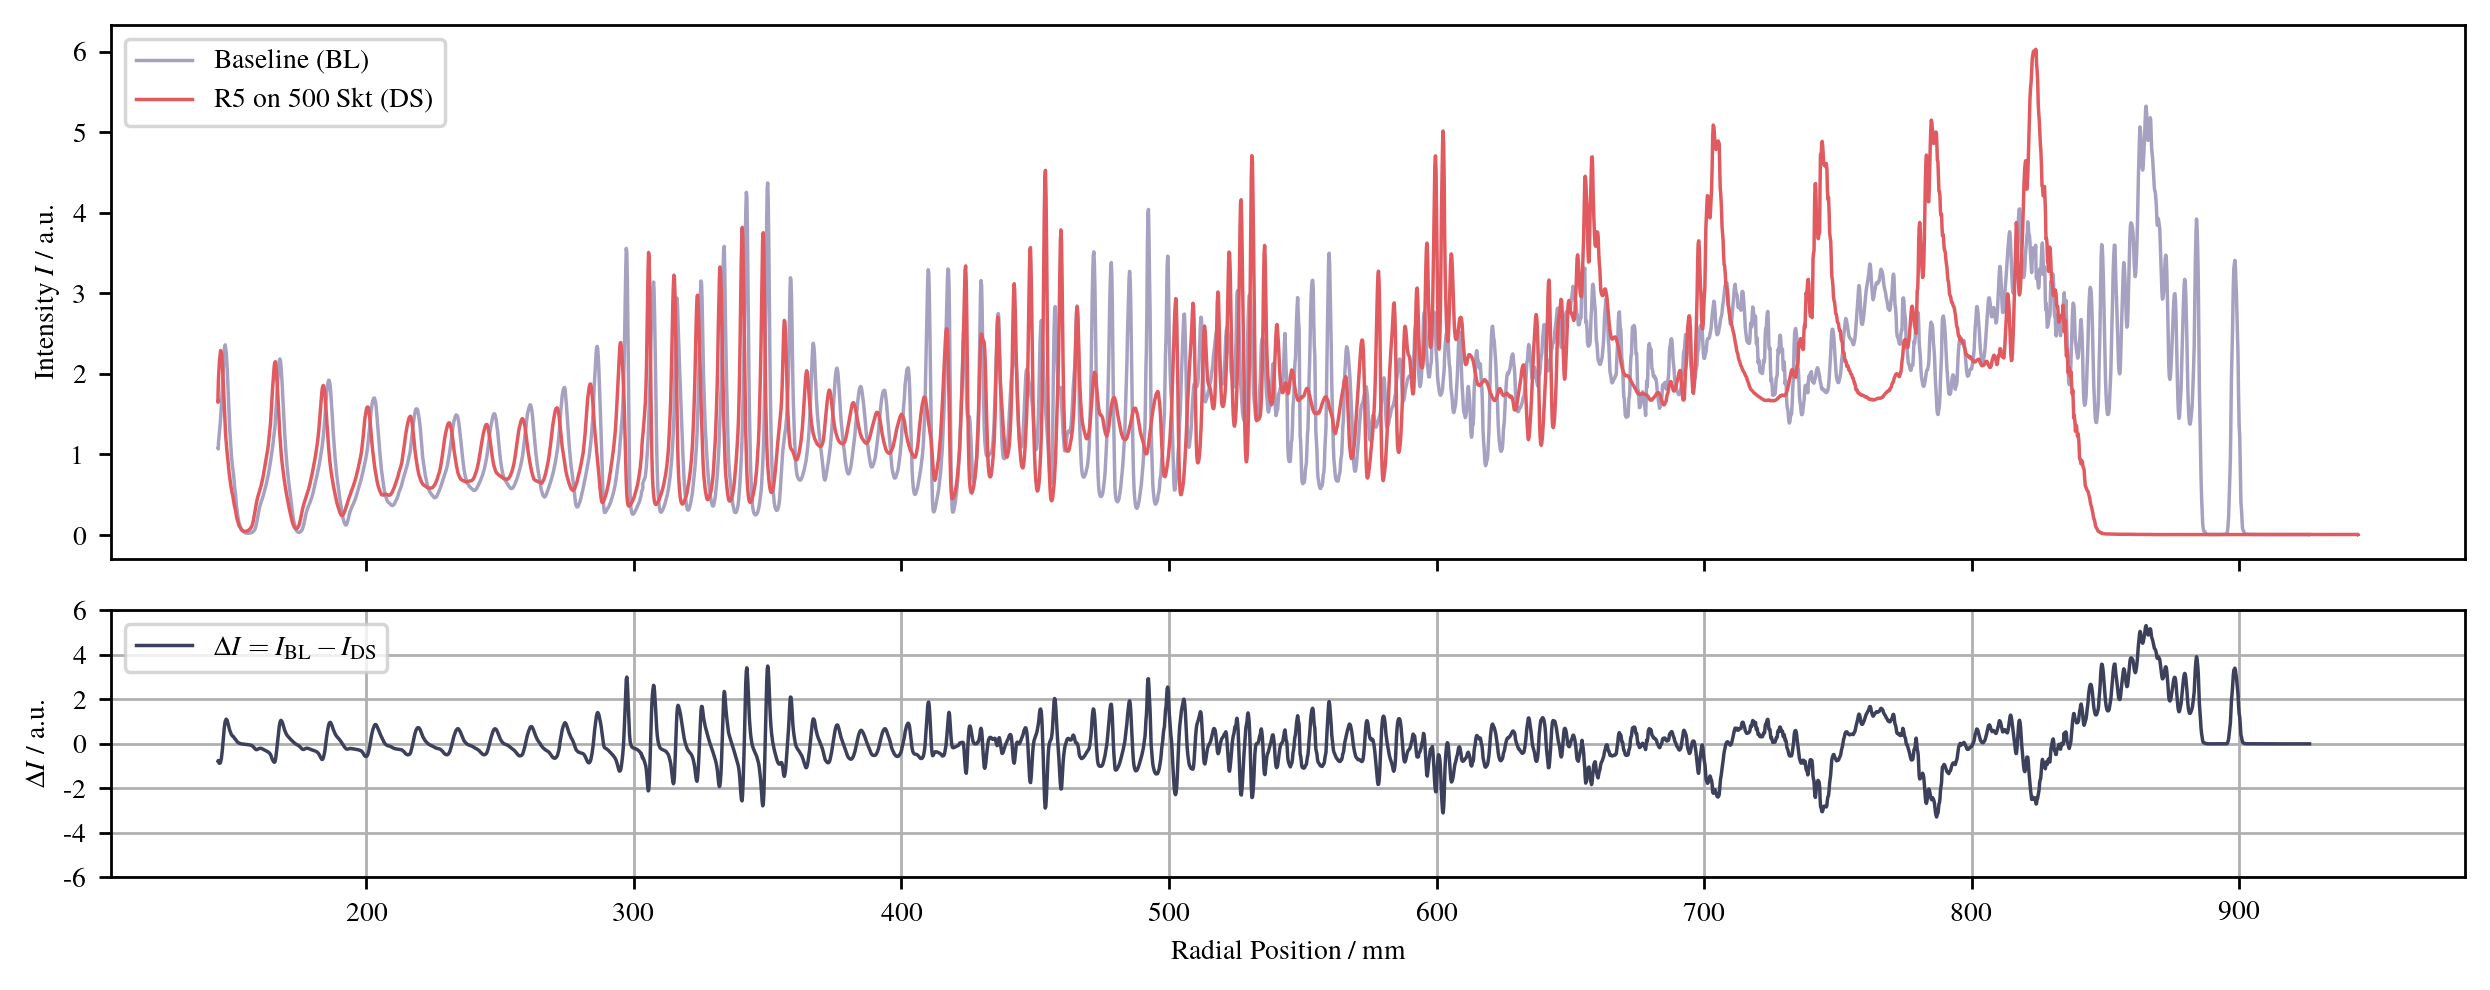

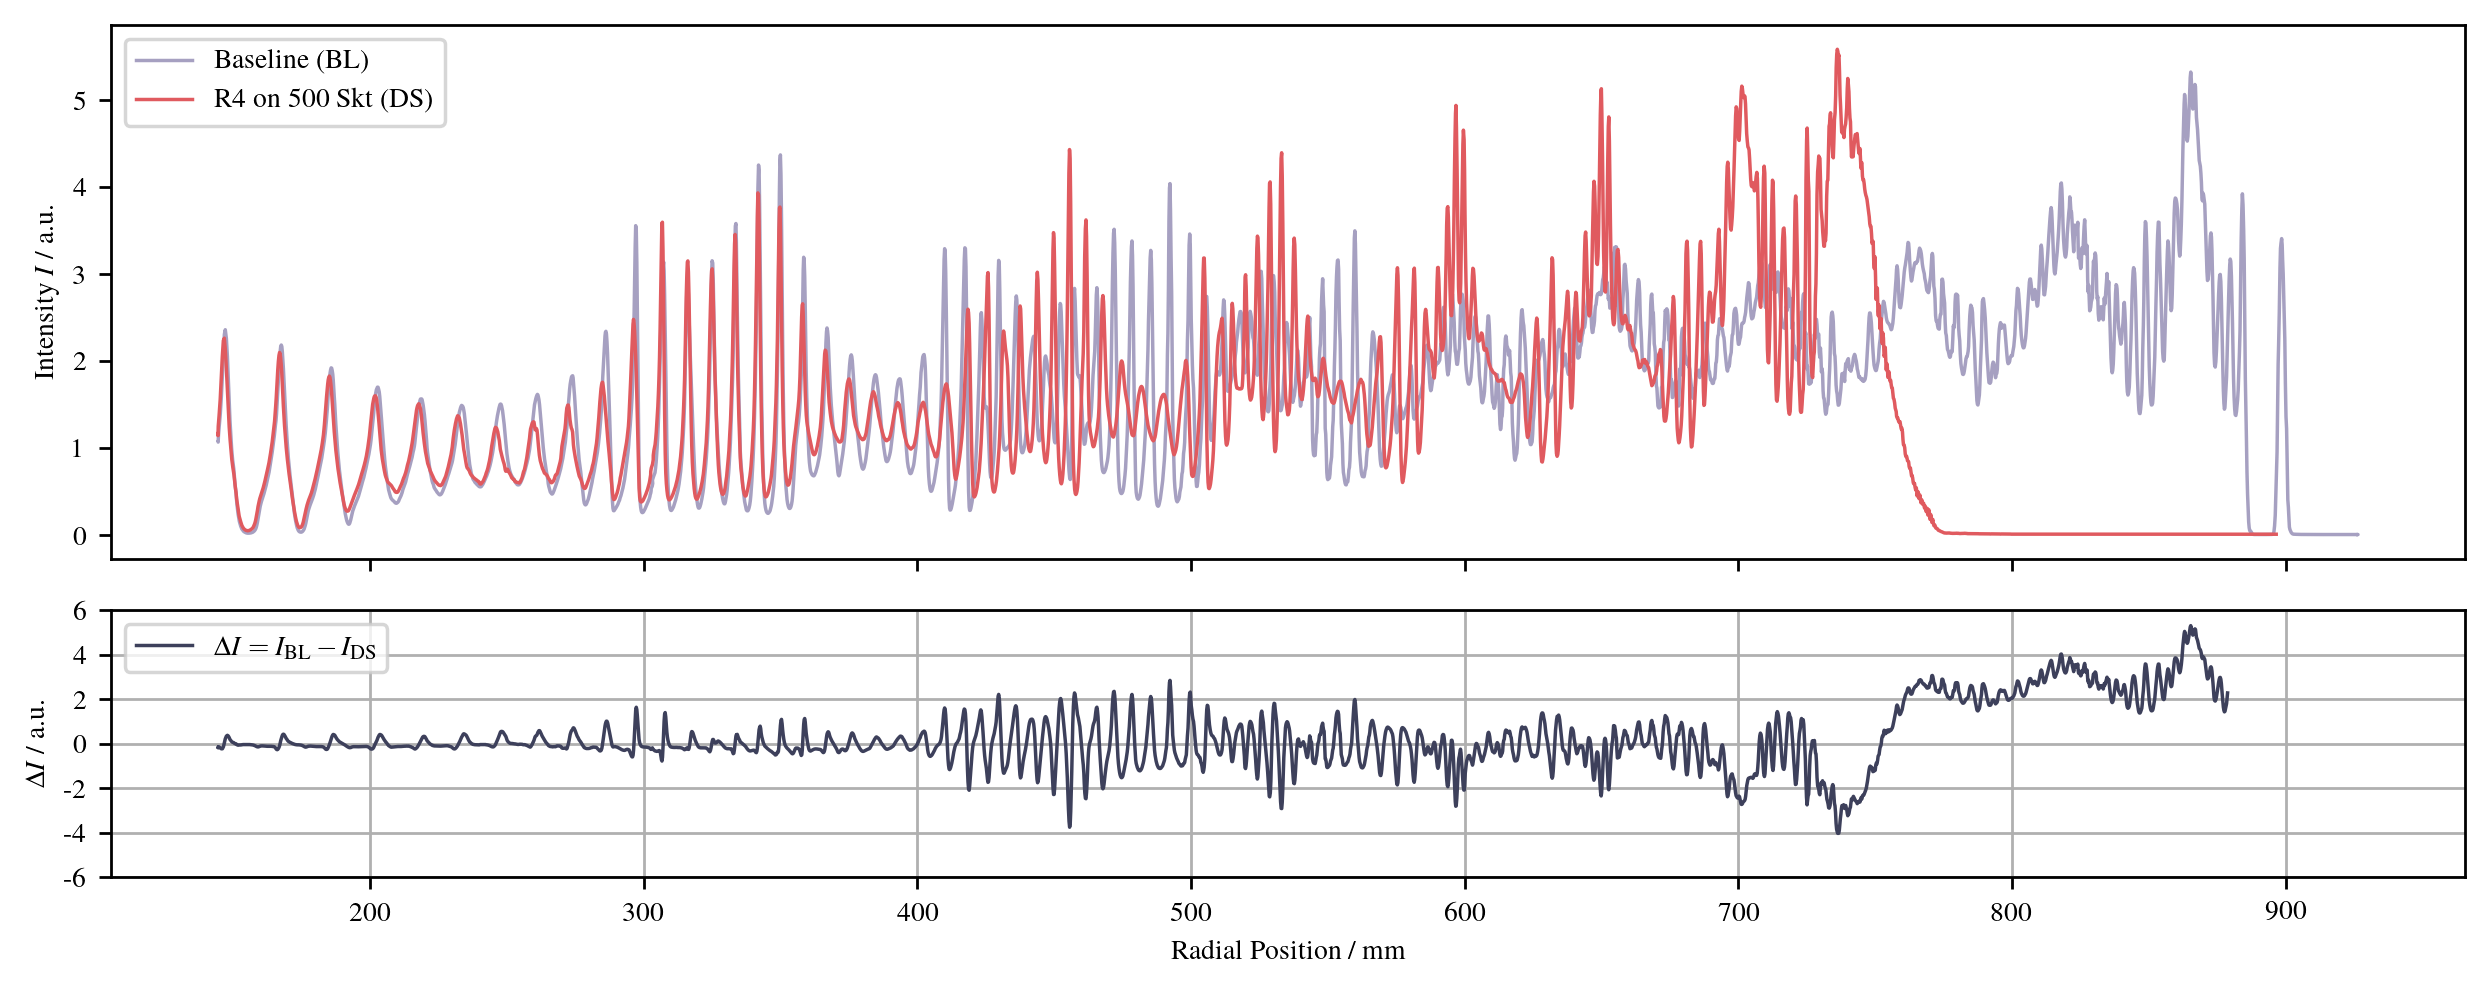

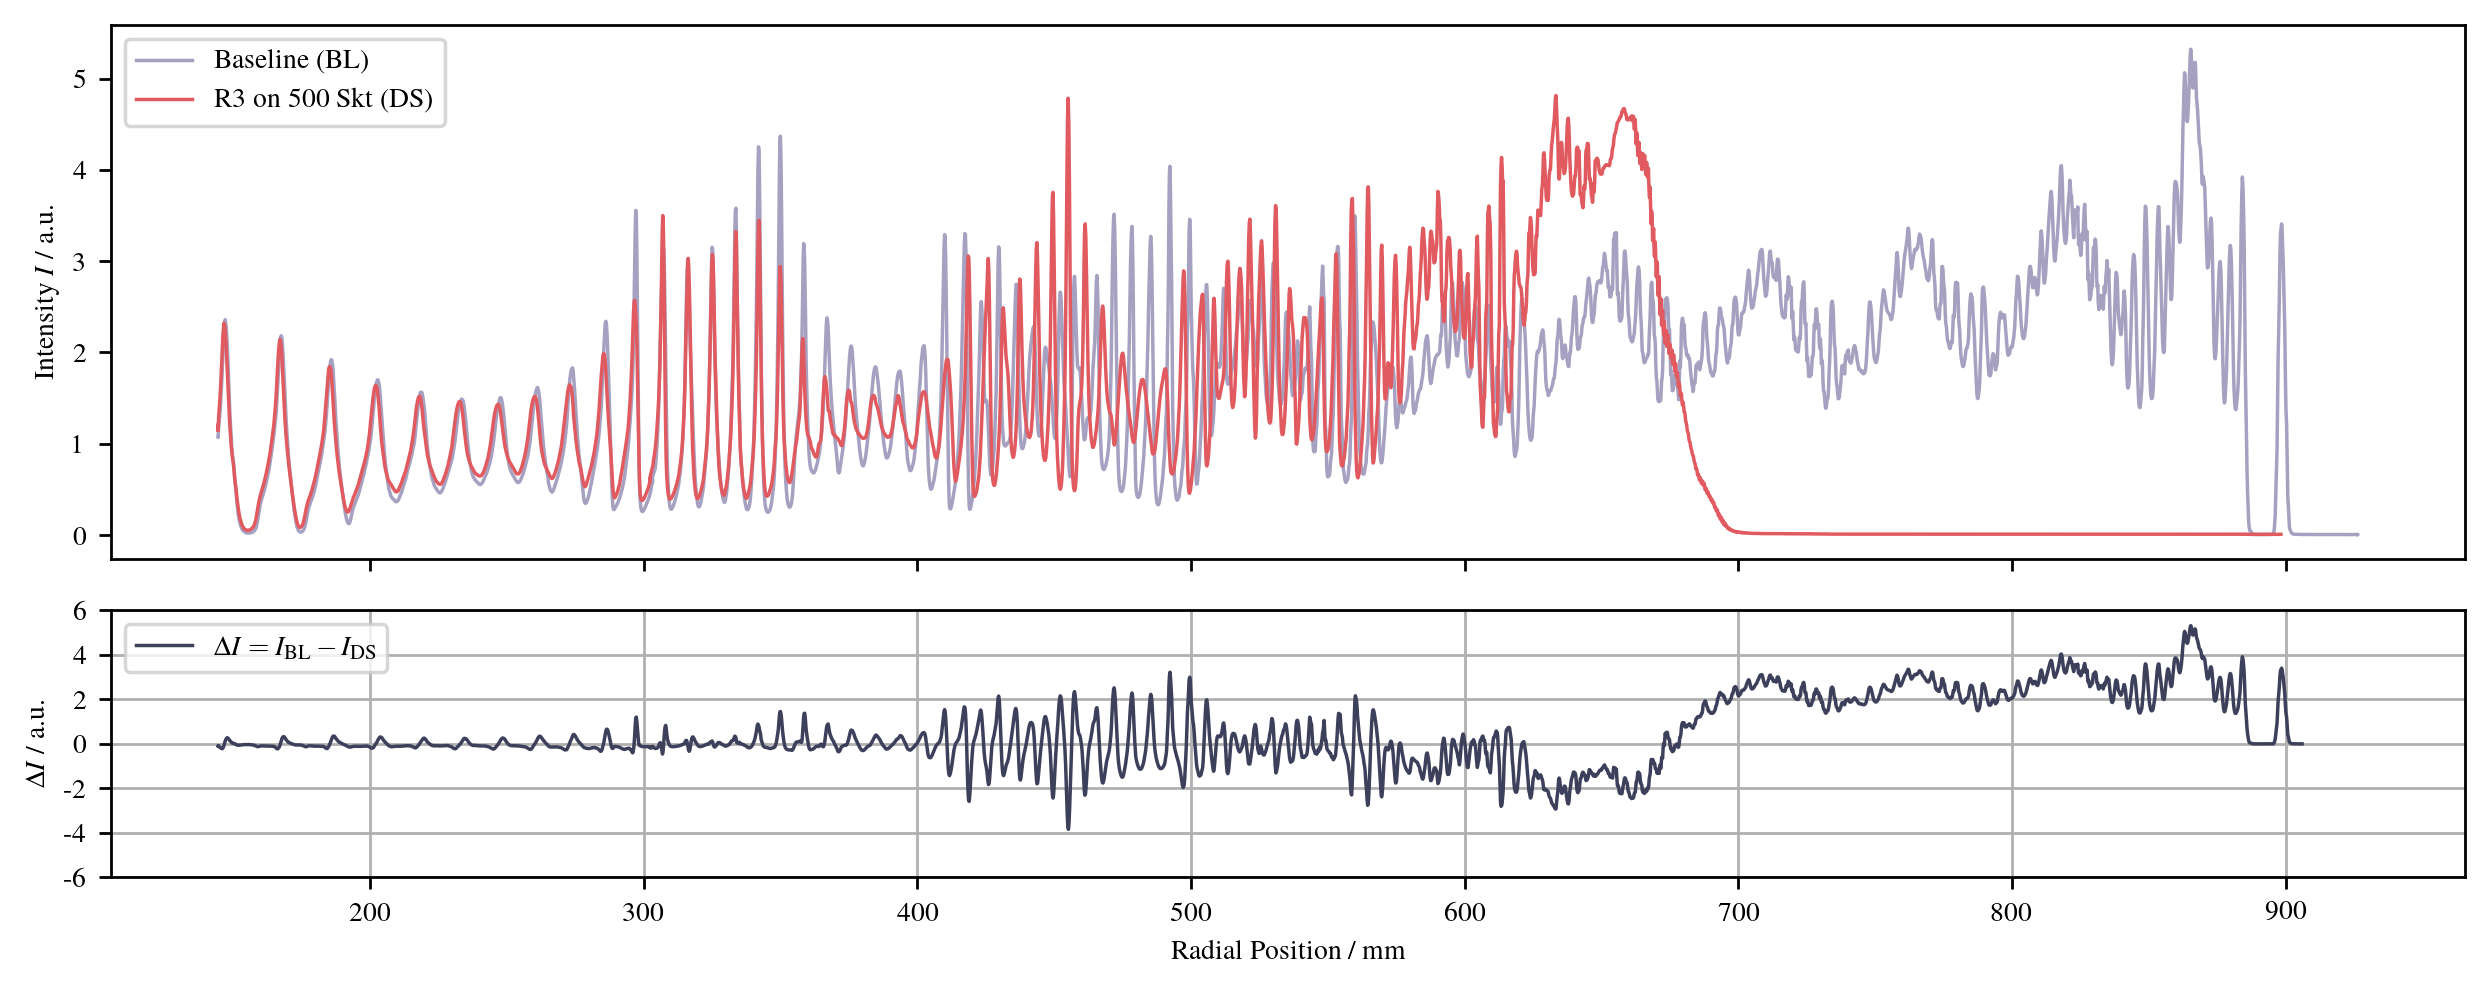

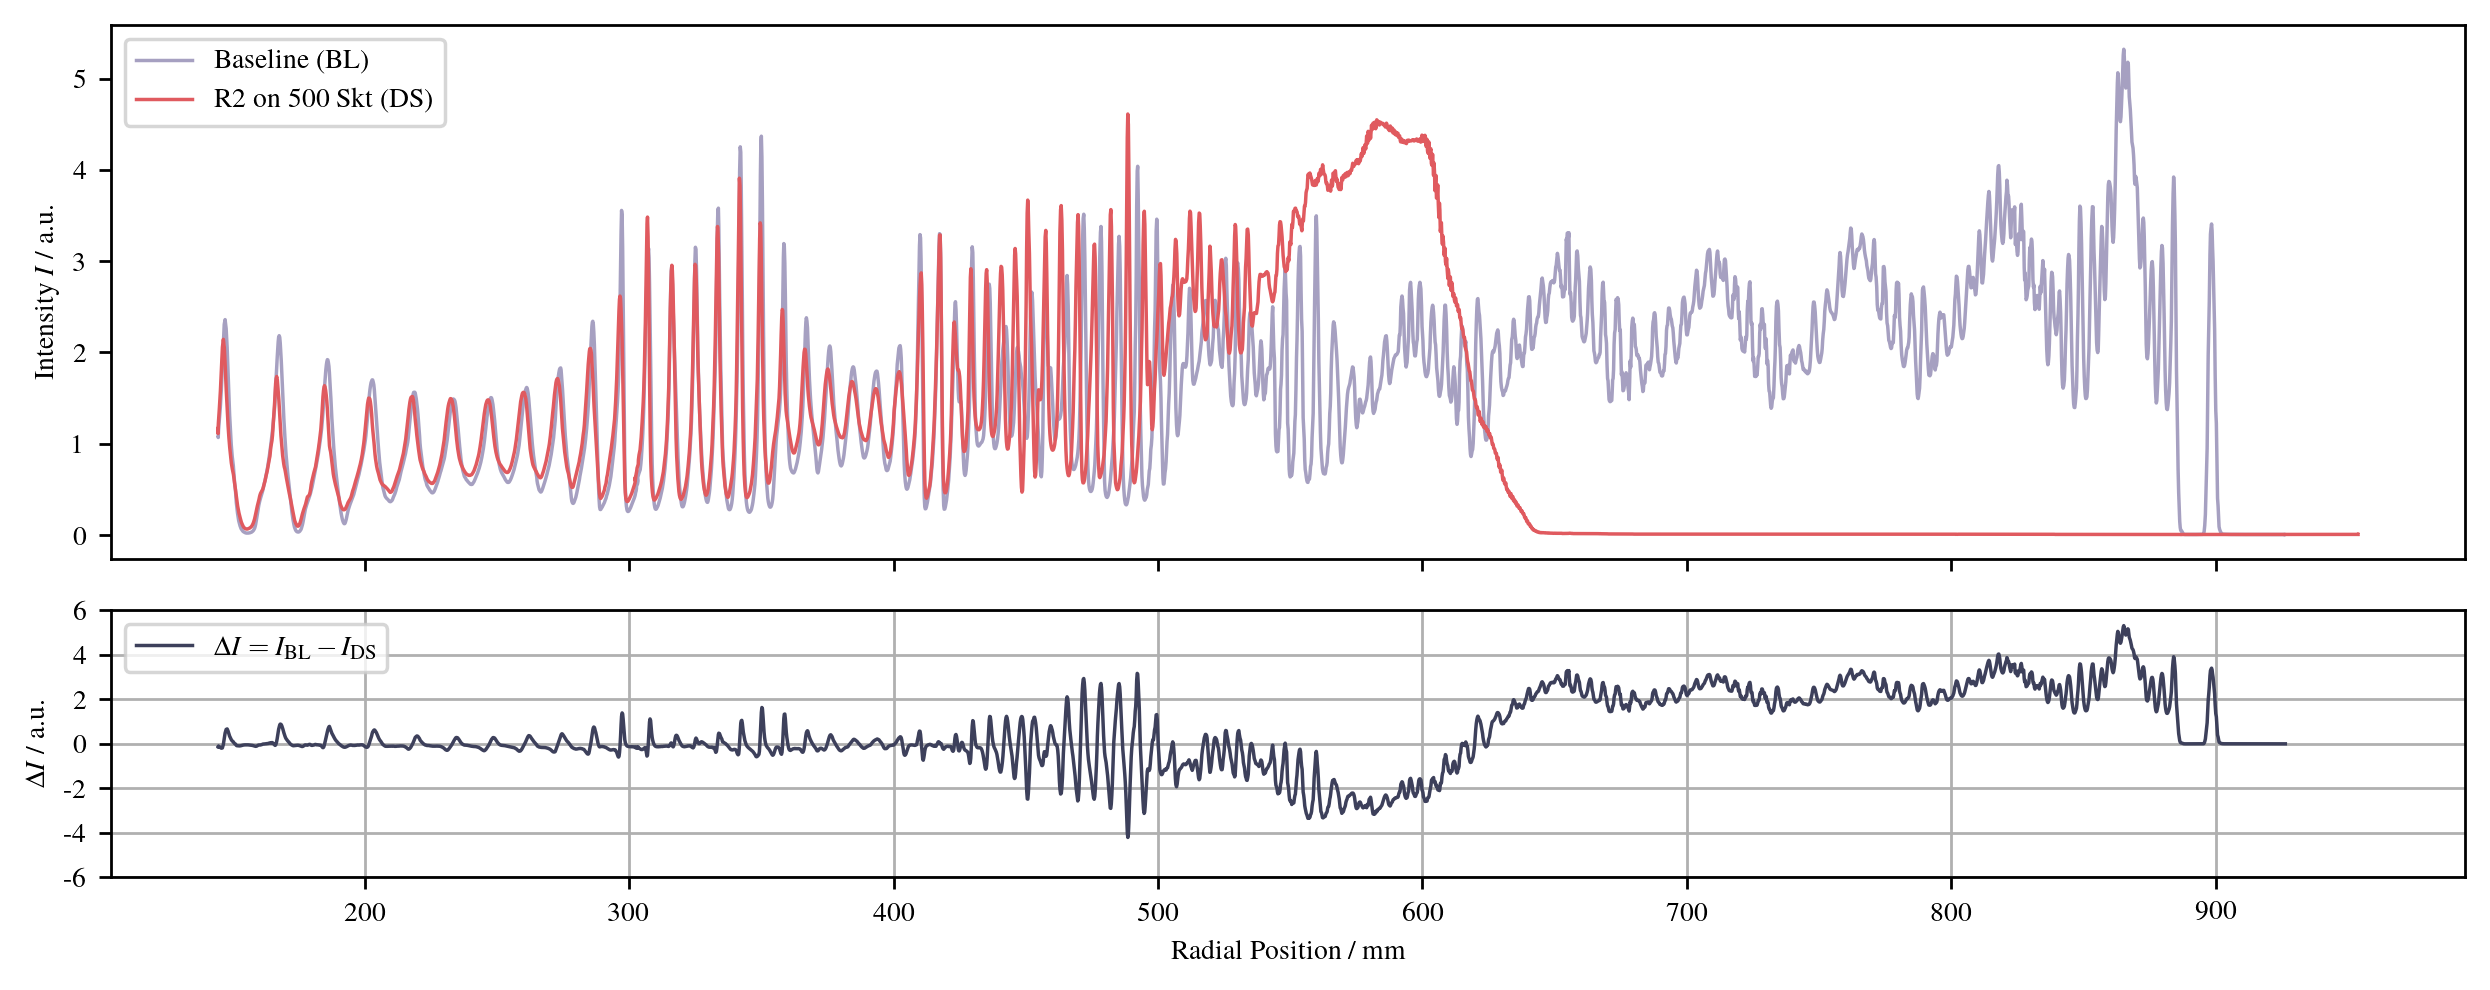

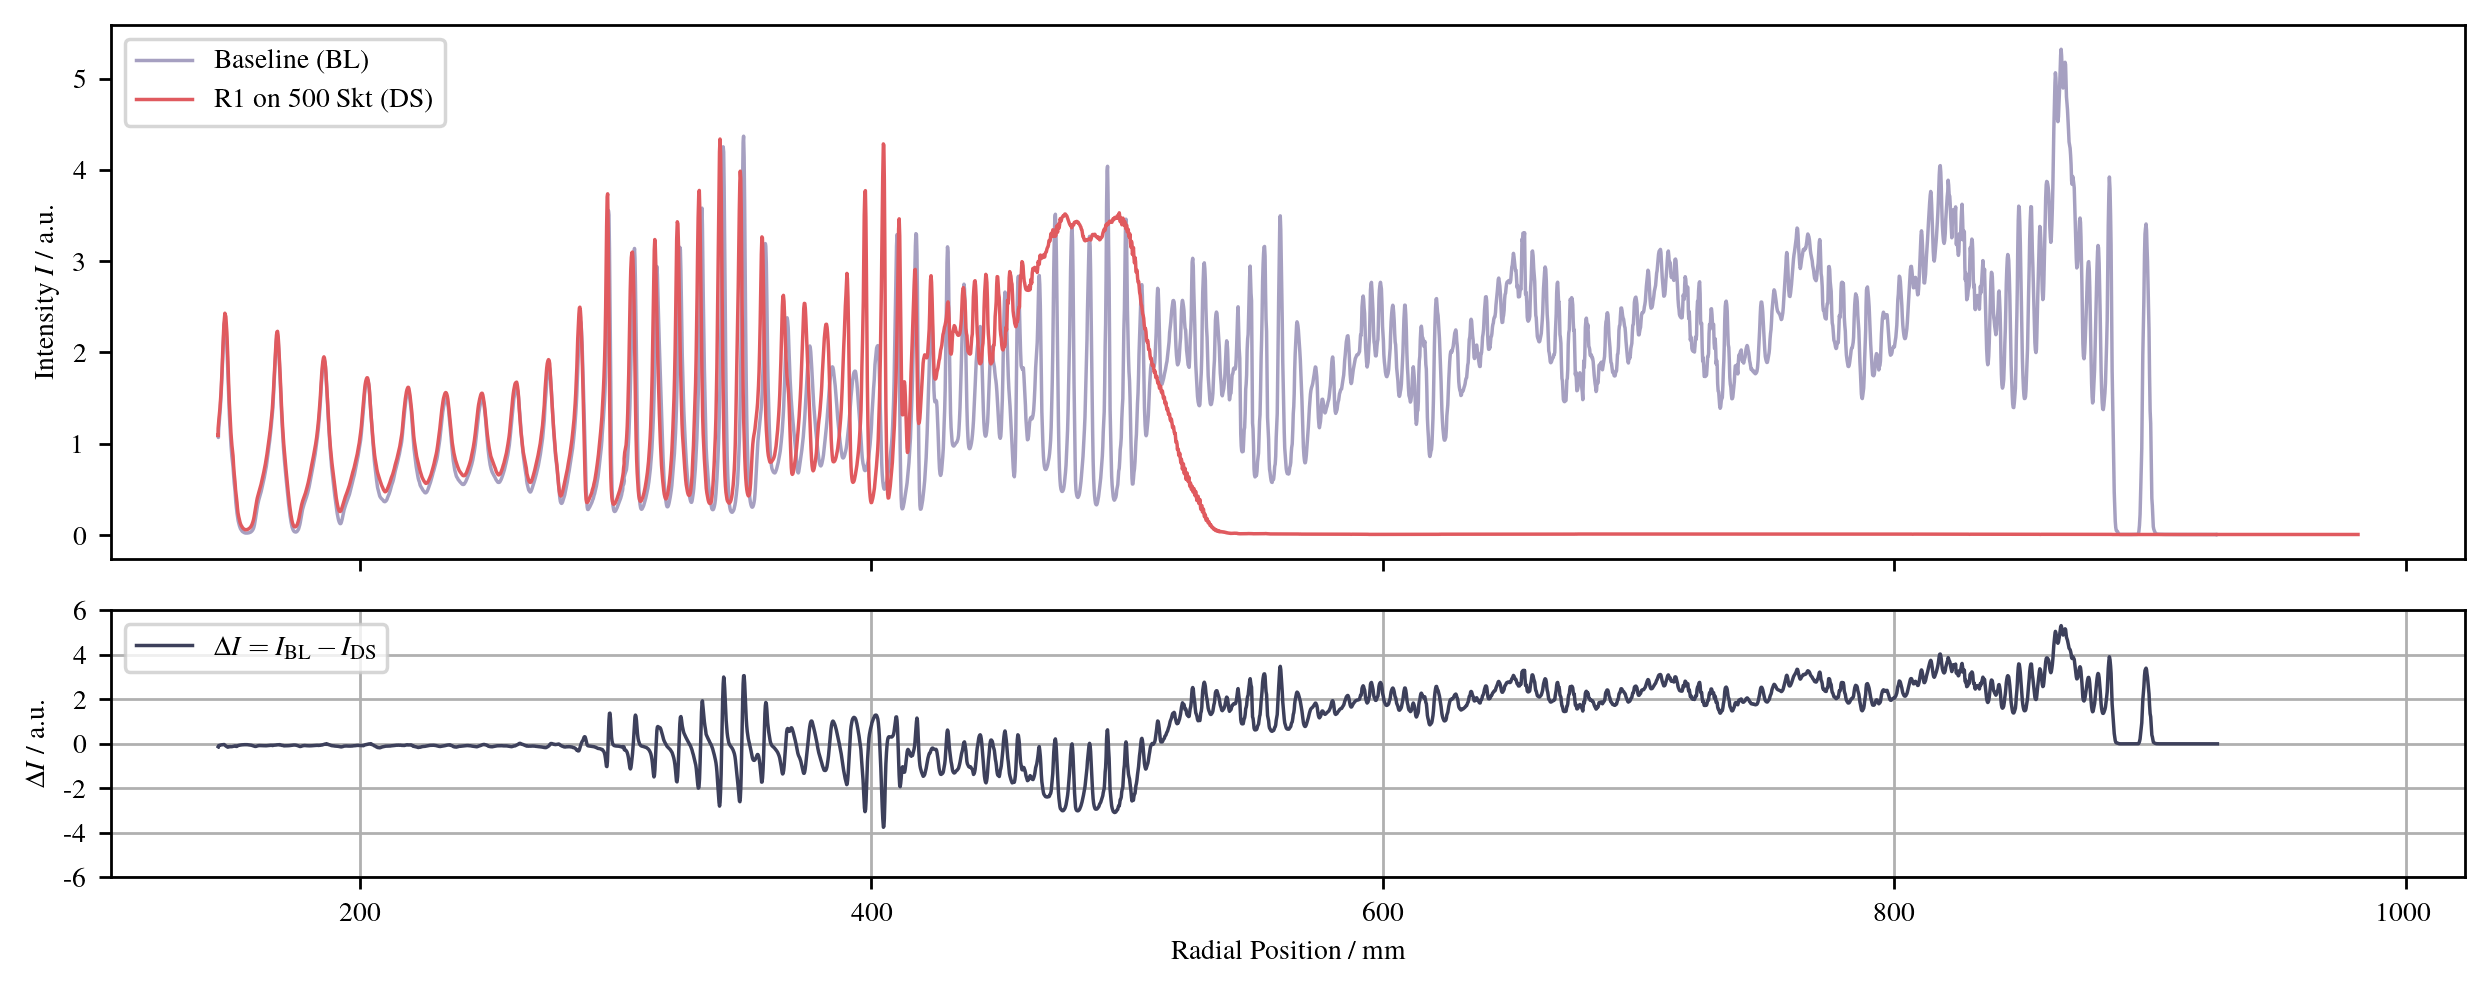

In [95]:
# diffs_of_DS_toBaseline(ds_info, './2026_KW16/DS_3.txt')
for file in os.listdir('./2026_KW16'):
    path = f'./2026_KW16/{file}'
    if os.path.isfile(path) == True and path not in ['./2026_KW16/DS_1.txt','./2026_KW16/DS_2.txt']:
        diffs_of_DS_toBaseline(ds_info, path)

## FFT of Spatial Separation Data

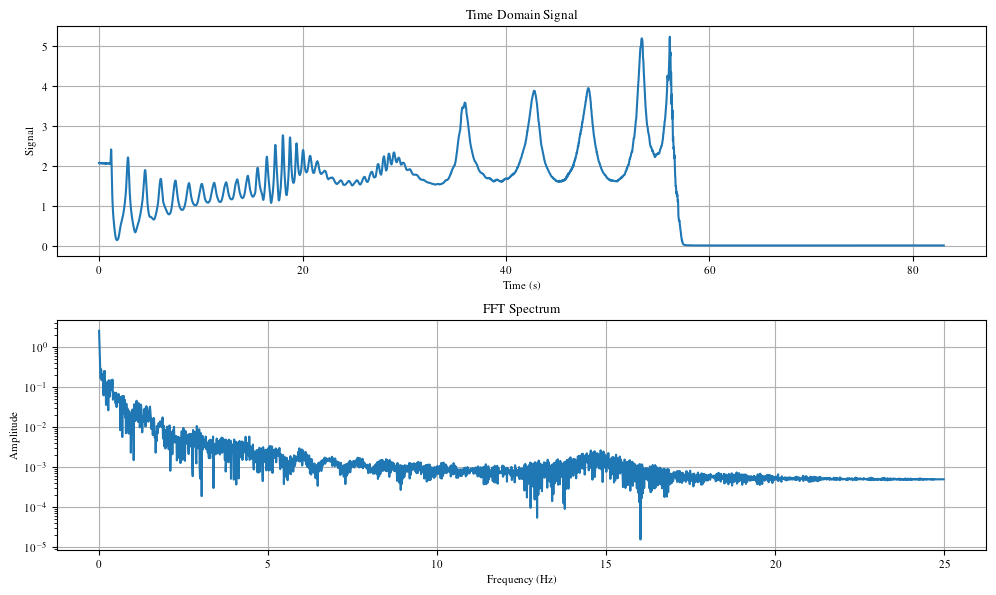

In [8]:
# ===== Load measurement data =====
# CSV format: time, signal
filename = './2026_KW16/DS_10.txt'
df = pd.read_csv(filename, skiprows=8, delimiter='\t', decimal=",")

time = df['Seconds']
signal = df['Real']

# ===== Sampling information =====
dt = time[1] - time[0]          # sampling interval
fs = 1/dt                       # sampling frequency
N = len(signal)                 # number of samples

# ===== FFT =====
fft_vals = np.fft.fft(signal)
fft_vals = fft_vals[:N//2]      # keep positive frequencies

freq = np.fft.fftfreq(N, dt)
freq = freq[:N//2]

amplitude = np.abs(fft_vals) / N * 2

# ===== Plot =====
plt.figure(figsize=(10,6))

# Time domain
plt.subplot(2,1,1)
plt.plot(time, signal)
plt.xlabel("Time (s)")
plt.ylabel("Signal")
plt.title("Time Domain Signal")
plt.grid()

# Frequency domain
plt.subplot(2,1,2)
plt.plot(freq, amplitude)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.yscale('log')
plt.title("FFT Spectrum")
plt.grid()

plt.tight_layout()
plt.show()